# Energy–Accuracy–Frequency Analysis — Corrected Paired Benchmark

This notebook analyzes the completed **420-run energy experiment** and pairs each energy measurement with the corresponding **per-sequence Experiment A accuracy**.

The sequence mapping is **method-aware**:

- H36M MoveEnet-only / MoveEnet + OFK:
  `camX_Subject_Sequence__ch0dvs`
- H36M OpenPose / YOLOPose:
  `camX_Subject_Sequence`
- DHP19 MoveEnet-only / MoveEnet + OFK / EventPointPose:
  `Sequence__ch2dvs` or `Sequence__ch3dvs`

The notebook performs a strict audit of all expected keys before any analysis. It stops unless all **420 sample–method–frequency keys** exist in the per-sequence accuracy table.

Primary question:

> Can MoveEnet + OFK run the DNN less frequently, preserve similar accuracy, and reduce measured compute energy?


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

BOOTSTRAP_SEED = 1
N_BOOTSTRAP = 5000


## 1. Configuration

In [2]:
# Run inside the MoveEnetOFK Docker container.

DATA_DIR = Path("/data")

ENERGY_RUN = (
    DATA_DIR
    / "MoveEnet_OFK_results"
    / "Energy"
    / "energy_accuracy_main"
)

ACCURACY_PER_SEQUENCE_CSV = (
    DATA_DIR
    / "moveEnetOFK"
    / "Comparison"
    / "selected_runs"
    / "dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose"
    / "results"
    / "comparison_per_sequence_metrics.csv"
)

NETWORK_PERIODS = np.array([0.02, 0.05, 0.1, 0.2, 0.5], dtype=float)
OFK_FLOW_PERIOD_S = 0.005

EXPECTED_METHODS = {
    "h36m": ["MoveEnet only", "MoveEnet + OFK", "OpenPose", "YOLOPose"],
    "dhp19": ["MoveEnet only", "MoveEnet + OFK", "EventPointPose"],
}

METHOD_FROM_ENERGY_DIR = {
    "movenet": "MoveEnet only",
    "moveenetofk": "MoveEnet + OFK",
    "openpose": "OpenPose",
    "yolo": "YOLOPose",
    "eventpointpose": "EventPointPose",
}

METHOD_MARKERS = {
    "MoveEnet only": "s",
    "MoveEnet + OFK": "o",
    "OpenPose": "^",
    "YOLOPose": "D",
    "EventPointPose": "v",
}

ANALYSIS_DIR = ENERGY_RUN / "analysis_corrected"
PLOTS_DIR = ANALYSIS_DIR / "plots"
TABLES_DIR = ANALYSIS_DIR / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("ENERGY_RUN:")
print(ENERGY_RUN)
print("\nACCURACY_PER_SEQUENCE_CSV:")
print(ACCURACY_PER_SEQUENCE_CSV)


ENERGY_RUN:
/data/MoveEnet_OFK_results/Energy/energy_accuracy_main

ACCURACY_PER_SEQUENCE_CSV:
/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/comparison_per_sequence_metrics.csv


## 2. Helper functions

In [3]:
def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")


def normalize_dataset(value):
    value = str(value).strip().lower()
    if value in {"eh36m", "h36m"}:
        return "h36m"
    if value == "dhp19":
        return "dhp19"
    return value


def find_column(df, aliases, required=True):
    normalized = {normalize_name(c): c for c in df.columns}

    for alias in aliases:
        key = normalize_name(alias)
        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"Could not find any of {aliases}. "
            f"Available columns: {list(df.columns)}"
        )

    return None


def canonical_method(value):
    s = str(value).strip()
    low = s.lower()

    if "moveenet" in low and ("ofk" in low or "flow" in low):
        return "MoveEnet + OFK"

    if "moveenet" in low and "only" in low:
        return "MoveEnet only"

    if low in {"movenet", "moveenet"}:
        return "MoveEnet only"

    if "eventpointpose" in low or "event point pose" in low:
        return "EventPointPose"

    if "openpose" in low:
        return "OpenPose"

    if "yolo" in low:
        return "YOLOPose"

    return s


def is_expected_period(series):
    values = np.asarray(series, dtype=float)

    return np.any(
        np.isclose(
            values[:, None],
            NETWORK_PERIODS[None, :],
            atol=1e-9,
        ),
        axis=1,
    )


def decode_np_dir(name):
    name = str(name)

    if not name.startswith("np_"):
        raise ValueError(
            f"Unexpected network-period directory: {name}"
        )

    return float(
        name[3:].replace("p", ".")
    )


def bootstrap_mean_ci(
    values,
    n_boot=N_BOOTSTRAP,
    seed=BOOTSTRAP_SEED,
):
    x = np.asarray(
        pd.Series(values).dropna(),
        dtype=float,
    )

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return float(x[0]), float(x[0])

    rng = np.random.default_rng(seed)

    indices = rng.integers(
        0,
        len(x),
        size=(n_boot, len(x)),
    )

    bootstrap_means = x[indices].mean(axis=1)

    low, high = np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )

    return float(low), float(high)


ENERGY_COLUMN_ALIASES = {
    "wall_seconds": [
        "wall_seconds",
        "wall_time_s",
        "wall_time_seconds",
        "elapsed_seconds",
    ],

    "cpu_energy_j": [
        "cpu_package_energy_j",
        "cpu_energy_j",
        "cpu_package_j",
        "rapl_package_energy_j",
    ],

    "gpu_energy_j": [
        "gpu_energy_j",
        "gpu_j",
        "nvml_gpu_energy_j",
    ],

    "combined_energy_j": [
        "measured_compute_energy_j",
        "combined_energy_j",
        "compute_energy_j",
        "cpu_gpu_energy_j",
        "total_compute_energy_j",
    ],
}


def canonicalize_energy_columns(df):
    out = df.copy()
    rename = {}

    for canonical, aliases in ENERGY_COLUMN_ALIASES.items():

        found = find_column(
            out,
            aliases,
            required=False,
        )

        if found is not None:
            rename[found] = canonical

    out = out.rename(columns=rename)

    for required in [
        "wall_seconds",
        "cpu_energy_j",
        "gpu_energy_j",
    ]:
        if required not in out.columns:
            raise KeyError(
                f"Missing required energy column '{required}'. "
                f"Available columns: {list(df.columns)}"
            )

    if "combined_energy_j" not in out.columns:
        out["combined_energy_j"] = (
            out["cpu_energy_j"]
            + out["gpu_energy_j"]
        )

    return out


def expected_accuracy_sequence(row):
    """Map one energy row to the exact sequence key used by ExpA comparison."""

    dataset = row["dataset"]
    method = row["method"]

    subject = str(row.get("subject", ""))
    sequence = str(row.get("sequence", ""))
    camera = str(row.get("camera", ""))

    if dataset == "h36m":

        base = f"{camera}_{subject}_{sequence}"

        if method in [
            "MoveEnet only",
            "MoveEnet + OFK",
        ]:
            return f"{base}__ch0dvs"

        if method in [
            "OpenPose",
            "YOLOPose",
        ]:
            return base

        raise ValueError(
            f"Unexpected H36M method: {method}"
        )

    if dataset == "dhp19":

        if method in [
            "MoveEnet only",
            "MoveEnet + OFK",
            "EventPointPose",
        ]:
            return f"{sequence}__{camera}"

        raise ValueError(
            f"Unexpected DHP19 method: {method}"
        )

    raise ValueError(
        f"Unexpected dataset: {dataset}"
    )


## 3. Load the 420 energy measurements

This section validates:

- 420 energy files
- 12 sequences per method/frequency operating point
- manifest metadata needed for the exact sequence-key mapping


In [4]:
if not ENERGY_RUN.exists():
    raise FileNotFoundError(
        f"Energy run not found: {ENERGY_RUN}"
    )

manifest_path = ENERGY_RUN / "run_manifest.csv"

if not manifest_path.exists():
    raise FileNotFoundError(
        f"Missing manifest: {manifest_path}"
    )

manifest = pd.read_csv(manifest_path)

manifest["dataset"] = (
    manifest["dataset"]
    .map(normalize_dataset)
)

manifest["net_period"] = pd.to_numeric(
    manifest["net_period"],
    errors="coerce",
)

if "status" in manifest.columns:
    print("Run status:")
    display(
        manifest["status"]
        .value_counts(dropna=False)
        .to_frame("count")
    )

energy_files = sorted(
    ENERGY_RUN.glob(
        "*/*/np_*/*/energy.csv"
    )
)

print("energy.csv files found:", len(energy_files))

energy_rows = []

for energy_path in energy_files:

    rel = energy_path.relative_to(
        ENERGY_RUN
    )

    dataset, sample_id, np_dir, model_dir, _ = rel.parts

    if model_dir not in METHOD_FROM_ENERGY_DIR:
        continue

    raw = pd.read_csv(
        energy_path
    )

    if len(raw) != 1:
        raise ValueError(
            f"{energy_path}: expected exactly 1 row, "
            f"found {len(raw)}"
        )

    e = canonicalize_energy_columns(
        raw
    ).iloc[0]

    np_s = decode_np_dir(
        np_dir
    )

    energy_rows.append({
        "dataset": normalize_dataset(dataset),
        "sample_id": sample_id,
        "method": METHOD_FROM_ENERGY_DIR[model_dir],
        "network_period_s": np_s,
        "detection_rate_hz": 1.0 / np_s,

        "wall_seconds": float(e["wall_seconds"]),
        "cpu_energy_j": float(e["cpu_energy_j"]),
        "gpu_energy_j": float(e["gpu_energy_j"]),
        "combined_energy_j": float(e["combined_energy_j"]),

        "energy_csv": str(energy_path),
    })


energy = pd.DataFrame(
    energy_rows
)

energy = energy[
    is_expected_period(
        energy["network_period_s"]
    )
].copy()


manifest_meta = manifest.copy()

manifest_meta["method"] = (
    manifest_meta["model"]
    .map(METHOD_FROM_ENERGY_DIR)
)


manifest_cols = [
    c
    for c in [
        "dataset",
        "sample_id",
        "method",
        "net_period",
        "subject",
        "sequence",
        "camera",
        "motion_class",
        "model_order_id",
        "model_order_position",
        "period_order_id",
        "period_order_position",
    ]
    if c in manifest_meta.columns
]


manifest_meta = (
    manifest_meta[manifest_cols]
    .rename(
        columns={
            "net_period":
                "network_period_s"
        }
    )
)


energy = energy.merge(
    manifest_meta,
    on=[
        "dataset",
        "sample_id",
        "method",
        "network_period_s",
    ],
    how="left",
    validate="one_to_one",
)


print("\nLoaded energy rows:", len(energy))

if len(energy) != 420:
    raise RuntimeError(
        f"Expected 420 energy rows, found {len(energy)}"
    )


counts = (
    energy
    .groupby(
        [
            "dataset",
            "method",
            "network_period_s",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n_sequences"
        }
    )
)


display(counts)


if not (
    counts["n_sequences"] == 12
).all():

    raise RuntimeError(
        "Some energy operating points "
        "do not contain 12 sequences."
    )


print(
    "ENERGY QC PASSED: "
    "420 runs, 12 sequences per operating point."
)


Run status:


,count
status,
OK,420


energy.csv files found: 420

Loaded energy rows: 420


,dataset,method,network_period_s,n_sequences
0,dhp19,EventPointPose,0.02,12
1,dhp19,EventPointPose,0.05,12
2,dhp19,EventPointPose,0.10,12
3,dhp19,EventPointPose,0.20,12
4,dhp19,EventPointPose,0.50,12
5,dhp19,MoveEnet + OFK,0.02,12
6,dhp19,MoveEnet + OFK,0.05,12
7,dhp19,MoveEnet + OFK,0.10,12
8,dhp19,MoveEnet + OFK,0.20,12
9,dhp19,MoveEnet + OFK,0.50,12


ENERGY QC PASSED: 420 runs, 12 sequences per operating point.


## 4. Load and normalize the per-sequence accuracy table

This is the file produced by the existing ExpA comparison notebook.


In [5]:
if not ACCURACY_PER_SEQUENCE_CSV.exists():

    raise FileNotFoundError(
        f"Per-sequence accuracy file not found:\n"
        f"{ACCURACY_PER_SEQUENCE_CSV}"
    )


seq_raw = pd.read_csv(
    ACCURACY_PER_SEQUENCE_CSV
)


print("Raw per-sequence rows:", len(seq_raw))

print("\nColumns:")
print(list(seq_raw.columns))

display(
    seq_raw.head()
)


Raw per-sequence rows: 3397

Columns:
['dataset', 'family', 'sequence', 'method', 'method_variant', 'flow_period_s', 'network_period_s', 'detection_rate_hz', 'csv_path', 'gt_path', 'n_samples', 'n_points', 'sum_err_px', 'mpjpe_px', 'pck_0.2', 'pck_0.2_correct_points', 'pck_0.4', 'pck_0.4_correct_points']


,dataset,family,sequence,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,csv_path,gt_path,n_samples,n_points,sum_err_px,mpjpe_px,pck_0.2,pck_0.2_correct_points,pck_0.4,pck_0.4_correct_points
0,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,4185,54405,1.876751e+06,34.495920,11.535704,6276.0,21.867476,11897.0
1,dhp19,EventPointPose,S13_1_1__ch3dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,4188,54444,5.741911e+05,10.546453,60.432739,32902.0,90.726250,49395.0
2,dhp19,EventPointPose,S13_1_2__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,3888,50544,1.040154e+06,20.579184,44.398941,22441.0,66.189857,33455.0
3,dhp19,EventPointPose,S13_1_2__ch3dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,3989,51857,5.717505e+05,11.025522,57.303738,29716.0,89.536613,46431.0
4,dhp19,EventPointPose,S13_1_3__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,3470,45110,1.035211e+06,22.948586,41.729107,18824.0,59.807140,26979.0


In [6]:
dataset_col = find_column(
    seq_raw,
    ["dataset"],
)

sequence_col = find_column(
    seq_raw,
    ["sequence"],
)

np_col = find_column(
    seq_raw,
    [
        "network_period_s",
        "net_period",
        "network_period",
    ],
)

method_col = find_column(
    seq_raw,
    ["method"],
    required=False,
)

variant_col = find_column(
    seq_raw,
    ["method_variant"],
    required=False,
)

flow_col = find_column(
    seq_raw,
    [
        "flow_period_s",
        "flow_period",
    ],
    required=False,
)

mpjpe_col = find_column(
    seq_raw,
    [
        "mpjpe_px",
        "mpjpe",
    ],
)

pck_col = find_column(
    seq_raw,
    [
        "pck_0.2",
        "pck_0_2",
        "pck02",
    ],
)

n_points_col = find_column(
    seq_raw,
    [
        "n_points",
        "number_points",
        "valid_points",
    ],
    required=False,
)

sum_err_col = find_column(
    seq_raw,
    [
        "sum_err_px",
        "sum_error_px",
        "total_error_px",
    ],
    required=False,
)

pck_correct_col = find_column(
    seq_raw,
    [
        "pck_0.2_correct_points",
        "pck_0_2_correct_points",
        "pck02_correct_points",
    ],
    required=False,
)


if method_col is not None:

    method_source = seq_raw[
        method_col
    ]

elif variant_col is not None:

    method_source = seq_raw[
        variant_col
    ]

else:

    raise KeyError(
        "Neither 'method' nor "
        "'method_variant' found."
    )


seq_acc = pd.DataFrame({

    "dataset":
        seq_raw[dataset_col]
        .map(normalize_dataset),

    "accuracy_sequence":
        seq_raw[sequence_col]
        .astype(str),

    "method":
        method_source
        .map(canonical_method),

    "network_period_s":
        pd.to_numeric(
            seq_raw[np_col],
            errors="coerce",
        ),

    "mpjpe_px":
        pd.to_numeric(
            seq_raw[mpjpe_col],
            errors="coerce",
        ),

    "pck_0.2":
        pd.to_numeric(
            seq_raw[pck_col],
            errors="coerce",
        ),
})


seq_acc["flow_period_s"] = (
    pd.to_numeric(
        seq_raw[flow_col],
        errors="coerce",
    )
    if flow_col is not None
    else np.nan
)


seq_acc["n_points"] = (
    pd.to_numeric(
        seq_raw[n_points_col],
        errors="coerce",
    )
    if n_points_col is not None
    else np.nan
)


seq_acc["sum_err_px"] = (
    pd.to_numeric(
        seq_raw[sum_err_col],
        errors="coerce",
    )
    if sum_err_col is not None
    else np.nan
)


seq_acc["pck_0.2_correct_points"] = (
    pd.to_numeric(
        seq_raw[pck_correct_col],
        errors="coerce",
    )
    if pck_correct_col is not None
    else np.nan
)


# Convert [0,1] representation to percent if needed.
finite_pck = (
    seq_acc["pck_0.2"]
    .dropna()
)

if (
    len(finite_pck)
    and finite_pck.quantile(0.95) <= 1.5
):

    seq_acc["pck_0.2"] *= 100.0


# Common energy frequency grid only.
seq_acc = seq_acc[
    is_expected_period(
        seq_acc["network_period_s"]
    )
].copy()


# OFK: keep only fp = 0.005.
is_ofk = (
    seq_acc["method"]
    .eq("MoveEnet + OFK")
)

if flow_col is not None:

    correct_flow = np.isclose(
        seq_acc["flow_period_s"]
        .fillna(np.inf),

        OFK_FLOW_PERIOD_S,

        atol=1e-9,
    )

    seq_acc = seq_acc[
        (~is_ofk)
        | correct_flow
    ].copy()


allowed_pairs = {
    (dataset, method)

    for dataset, methods
    in EXPECTED_METHODS.items()

    for method
    in methods
}


seq_acc = seq_acc[
    [
        (dataset, method)
        in allowed_pairs

        for dataset, method
        in zip(
            seq_acc["dataset"],
            seq_acc["method"],
        )
    ]
].copy()


seq_acc["detection_rate_hz"] = (
    1.0
    / seq_acc["network_period_s"]
)


print(
    "Normalized per-sequence accuracy rows:",
    len(seq_acc),
)

display(
    seq_acc[
        [
            "dataset",
            "accuracy_sequence",
            "method",
            "network_period_s",
            "detection_rate_hz",
            "flow_period_s",
            "pck_0.2",
            "mpjpe_px",
            "n_points",
        ]
    ].head(20)
)


Normalized per-sequence accuracy rows: 3318


,dataset,accuracy_sequence,method,network_period_s,detection_rate_hz,flow_period_s,pck_0.2,mpjpe_px,n_points
79,dhp19,S13_1_1__ch2dvs,EventPointPose,0.02,50.0,NaN,12.057963,34.329233,54379
80,dhp19,S13_1_1__ch3dvs,EventPointPose,0.02,50.0,NaN,60.148041,10.670573,54444
81,dhp19,S13_1_2__ch2dvs,EventPointPose,0.02,50.0,NaN,43.023899,21.073026,50544
82,dhp19,S13_1_2__ch3dvs,EventPointPose,0.02,50.0,NaN,57.272888,11.133145,51857
83,dhp19,S13_1_3__ch2dvs,EventPointPose,0.02,50.0,NaN,43.209930,22.142247,45110
84,dhp19,S13_1_3__ch3dvs,EventPointPose,0.02,50.0,NaN,53.309639,12.484713,45292
85,dhp19,S13_1_4__ch2dvs,EventPointPose,0.02,50.0,NaN,36.372196,22.544216,49920
86,dhp19,S13_1_4__ch3dvs,EventPointPose,0.02,50.0,NaN,49.860329,16.294529,105248
87,dhp19,S13_1_5__ch2dvs,EventPointPose,0.02,50.0,NaN,1.043231,41.384053,49270
88,dhp19,S13_1_5__ch3dvs,EventPointPose,0.02,50.0,NaN,39.474033,16.866192,104988


## 5. Build the exact method-aware accuracy key for all 420 energy rows

This is the corrected mapping.

The notebook prints a few examples so the keys can be inspected directly.


In [7]:
energy["accuracy_sequence"] = (
    energy.apply(
        expected_accuracy_sequence,
        axis=1,
    )
)


display(
    energy[
        [
            "dataset",
            "sample_id",
            "subject",
            "sequence",
            "camera",
            "method",
            "network_period_s",
            "accuracy_sequence",
        ]
    ]
    .sort_values(
        [
            "dataset",
            "sample_id",
            "network_period_s",
            "method",
        ]
    )
    .head(30)
)


,dataset,sample_id,subject,sequence,camera,method,network_period_s,accuracy_sequence
0,dhp19,D01,S13,S13_1_1,ch2dvs,EventPointPose,0.02,S13_1_1__ch2dvs
1,dhp19,D01,S13,S13_1_1,ch2dvs,MoveEnet + OFK,0.02,S13_1_1__ch2dvs
2,dhp19,D01,S13,S13_1_1,ch2dvs,MoveEnet only,0.02,S13_1_1__ch2dvs
3,dhp19,D01,S13,S13_1_1,ch2dvs,EventPointPose,0.05,S13_1_1__ch2dvs
4,dhp19,D01,S13,S13_1_1,ch2dvs,MoveEnet + OFK,0.05,S13_1_1__ch2dvs
5,dhp19,D01,S13,S13_1_1,ch2dvs,MoveEnet only,0.05,S13_1_1__ch2dvs
6,dhp19,D01,S13,S13_1_1,ch2dvs,EventPointPose,0.10,S13_1_1__ch2dvs
7,dhp19,D01,S13,S13_1_1,ch2dvs,MoveEnet + OFK,0.10,S13_1_1__ch2dvs
8,dhp19,D01,S13,S13_1_1,ch2dvs,MoveEnet only,0.10,S13_1_1__ch2dvs
9,dhp19,D01,S13,S13_1_1,ch2dvs,EventPointPose,0.20,S13_1_1__ch2dvs


## 6. STRICT 420-key audit — must pass before any graph

The audit checks the exact key:

`dataset + accuracy_sequence + method + network_period_s`

No interpolation, fallback, or silent dropping is allowed here.


In [8]:
# =============================================================================
# TEMPORARY PATCH:
# strict completeness for MoveEnet / OFK,
# allow explicitly reported missing baseline accuracy points
# =============================================================================

KEY = [
    "dataset",
    "accuracy_sequence",
    "method",
    "network_period_s",
]

CORE_METHODS = [
    "MoveEnet only",
    "MoveEnet + OFK",
]

expected_keys = (
    energy[KEY]
    .drop_duplicates()
    .reset_index(drop=True)
)

available_keys = (
    seq_acc[KEY]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Expected energy keys :", len(expected_keys))
print("Available accuracy keys:", len(available_keys))


# -------------------------------------------------------------------------
# Check duplicate accuracy records first.
# -------------------------------------------------------------------------

duplicate_acc = seq_acc.duplicated(
    KEY,
    keep=False,
)

if duplicate_acc.any():

    display(
        seq_acc.loc[
            duplicate_acc,
            KEY + [
                "flow_period_s",
                "pck_0.2",
                "mpjpe_px",
            ],
        ].sort_values(KEY)
    )

    raise RuntimeError(
        "Duplicate accuracy keys remain after filtering."
    )


# -------------------------------------------------------------------------
# Find missing energy -> accuracy keys.
# -------------------------------------------------------------------------

audit = expected_keys.merge(
    available_keys,
    on=KEY,
    how="left",
    indicator=True,
)

missing_keys = (
    audit[
        audit["_merge"] != "both"
    ]
    .drop(columns="_merge")
    .reset_index(drop=True)
)

print("\nTOTAL missing accuracy keys:", len(missing_keys))

if not missing_keys.empty:

    missing_summary = (
        missing_keys
        .groupby(
            [
                "dataset",
                "method",
                "network_period_s",
            ],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "n_missing"})
    )

    missing_summary["frequency_hz"] = (
        1.0 / missing_summary["network_period_s"]
    )

    display(missing_summary)

    missing_keys.to_csv(
        TABLES_DIR / "TEMP_missing_accuracy_keys.csv",
        index=False,
    )


# -------------------------------------------------------------------------
# CRITICAL CHECK:
# MoveEnet-only and MoveEnet+OFK must be 100% complete.
# -------------------------------------------------------------------------

core_missing = missing_keys[
    missing_keys["method"].isin(CORE_METHODS)
].copy()

print("\nMissing CORE MoveEnet/OFK keys:", len(core_missing))

if not core_missing.empty:

    display(core_missing)

    raise RuntimeError(
        "STOP: MoveEnet / OFK paired accuracy is incomplete. "
        "The central energy-accuracy comparison cannot continue."
    )


# Expected core:
# H36M  : 12 * 2 * 5 = 120
# DHP19 : 12 * 2 * 5 = 120
# total : 240

core_expected = expected_keys[
    expected_keys["method"].isin(CORE_METHODS)
]

core_available = core_expected.merge(
    available_keys,
    on=KEY,
    how="inner",
)

print("Expected CORE keys :", len(core_expected))
print("Available CORE keys:", len(core_available))

if len(core_expected) != 240:
    raise RuntimeError(
        f"Expected 240 MoveEnet/OFK keys, found {len(core_expected)}."
    )

if len(core_available) != 240:
    raise RuntimeError(
        f"Expected 240 complete MoveEnet/OFK accuracy keys, "
        f"found {len(core_available)}."
    )


print(
    "\nPATCH QC PASSED:"
    "\n- all 420 energy runs remain available"
    "\n- MoveEnet/OFK accuracy is complete: 240/240"
    f"\n- baseline accuracy missing keys: {len(missing_keys)}"
    "\n- baseline missing values will NOT be interpolated"
)


Expected energy keys : 420
Available accuracy keys: 3318

TOTAL missing accuracy keys: 8


,dataset,method,network_period_s,n_missing,frequency_hz
0,dhp19,EventPointPose,0.02,2,50.0
1,h36m,YOLOPose,0.10,1,10.0
2,h36m,YOLOPose,0.20,3,5.0
3,h36m,YOLOPose,0.50,2,2.0



Missing CORE MoveEnet/OFK keys: 0
Expected CORE keys : 240
Available CORE keys: 240

PATCH QC PASSED:
- all 420 energy runs remain available
- MoveEnet/OFK accuracy is complete: 240/240
- baseline accuracy missing keys: 8
- baseline missing values will NOT be interpolated


In [9]:
# ============================================================
# DIAGNOSE THE MISSING ACCURACY KEYS
# ============================================================

missing_path = (
    TABLES_DIR
    / "MISSING_ACCURACY_KEYS.csv"
)

missing = pd.read_csv(missing_path)

print("TOTAL MISSING KEYS:", len(missing))

print("\n========================================")
print("MISSING BY DATASET / METHOD / FREQUENCY")
print("========================================")

missing_summary = (
    missing
    .groupby(
        [
            "dataset",
            "method",
            "network_period_s",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n_missing"})
)

missing_summary["frequency_hz"] = (
    1.0 / missing_summary["network_period_s"]
)

display(
    missing_summary[
        [
            "dataset",
            "method",
            "frequency_hz",
            "network_period_s",
            "n_missing",
        ]
    ]
)


# ------------------------------------------------------------
# Determine at which level the match fails.
# ------------------------------------------------------------

diagnostic_rows = []

for _, row in missing.iterrows():

    dataset = row["dataset"]
    sequence = row["accuracy_sequence"]
    method = row["method"]
    period = row["network_period_s"]

    same_dataset = seq_acc[
        seq_acc["dataset"] == dataset
    ]

    same_sequence = same_dataset[
        same_dataset["accuracy_sequence"] == sequence
    ]

    same_method = same_sequence[
        same_sequence["method"] == method
    ]

    available_methods = sorted(
        same_sequence["method"]
        .dropna()
        .unique()
        .tolist()
    )

    available_periods = sorted(
        same_method["network_period_s"]
        .dropna()
        .unique()
        .tolist()
    )

    diagnostic_rows.append(
        {
            "dataset": dataset,
            "accuracy_sequence": sequence,
            "method": method,
            "requested_period_s": period,
            "requested_hz": 1.0 / period,

            "sequence_exists":
                not same_sequence.empty,

            "method_exists_for_sequence":
                not same_method.empty,

            "available_methods":
                available_methods,

            "available_periods_s":
                available_periods,

            "available_rates_hz":
                [
                    round(1.0 / p, 6)
                    for p in available_periods
                ],
        }
    )


diagnostic = pd.DataFrame(diagnostic_rows)


print("\n========================================")
print("TYPE OF FAILURE")
print("========================================")

display(
    diagnostic
    .groupby(
        [
            "dataset",
            "method",
            "sequence_exists",
            "method_exists_for_sequence",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "n_missing"})
)


print("\n========================================")
print("ALL MISSING KEYS WITH AVAILABLE PERIODS")
print("========================================")

display(diagnostic)


diagnostic.to_csv(
    TABLES_DIR / "missing_accuracy_diagnostic.csv",
    index=False,
)


TOTAL MISSING KEYS: 8

MISSING BY DATASET / METHOD / FREQUENCY


,dataset,method,frequency_hz,network_period_s,n_missing
0,dhp19,EventPointPose,50.0,0.02,2
1,h36m,YOLOPose,10.0,0.10,1
2,h36m,YOLOPose,5.0,0.20,3
3,h36m,YOLOPose,2.0,0.50,2



TYPE OF FAILURE


,dataset,method,sequence_exists,method_exists_for_sequence,n_missing
0,dhp19,EventPointPose,True,True,2
1,h36m,YOLOPose,True,True,6



ALL MISSING KEYS WITH AVAILABLE PERIODS


,dataset,accuracy_sequence,method,requested_period_s,requested_hz,sequence_exists,method_exists_for_sequence,available_methods,available_periods_s,available_rates_hz
0,dhp19,S17_1_5__ch2dvs,EventPointPose,0.02,50.0,True,True,"[EventPointPose, MoveEnet + OFK, MoveEnet only]","[0.05, 0.1, 0.2, 0.5]","[20.0, 10.0, 5.0, 2.0]"
1,dhp19,S14_1_8__ch2dvs,EventPointPose,0.02,50.0,True,True,"[EventPointPose, MoveEnet + OFK, MoveEnet only]","[0.05, 0.1, 0.2, 0.5]","[20.0, 10.0, 5.0, 2.0]"
2,h36m,cam2_S9_Discussion_1,YOLOPose,0.50,2.0,True,True,"[OpenPose, YOLOPose]","[0.02, 0.05, 0.1, 0.2]","[50.0, 20.0, 10.0, 5.0]"
3,h36m,cam2_S9_Walking_1,YOLOPose,0.50,2.0,True,True,"[OpenPose, YOLOPose]","[0.02, 0.05, 0.1, 0.2]","[50.0, 20.0, 10.0, 5.0]"
4,h36m,cam2_S9_WalkDog,YOLOPose,0.10,10.0,True,True,"[OpenPose, YOLOPose]","[0.02, 0.05, 0.5]","[50.0, 20.0, 2.0]"
5,h36m,cam2_S9_WalkDog,YOLOPose,0.20,5.0,True,True,"[OpenPose, YOLOPose]","[0.02, 0.05, 0.5]","[50.0, 20.0, 2.0]"
6,h36m,cam2_S11_Eating_1,YOLOPose,0.20,5.0,True,True,"[OpenPose, YOLOPose]","[0.02, 0.05, 0.1, 0.5]","[50.0, 20.0, 10.0, 2.0]"
7,h36m,cam2_S11_SittingDown_1,YOLOPose,0.20,5.0,True,True,"[OpenPose, YOLOPose]","[0.02, 0.05, 0.1, 0.5]","[50.0, 20.0, 10.0, 2.0]"


## 7. Merge the 420 paired energy–accuracy rows

After the strict key audit, the merge must produce exactly 420 rows.


In [10]:
# =============================================================================
# PATCHED MERGE
# Keep all 420 energy runs.
# Accuracy is NaN only where the known baseline result is unavailable.
# =============================================================================

paired = energy.merge(
    seq_acc,
    on=KEY,
    how="left",
    suffixes=(
        "_energy",
        "_accuracy",
    ),
    validate="one_to_one",
)


print("Energy rows retained:", len(paired))

if len(paired) != 420:

    raise RuntimeError(
        f"Expected 420 energy rows after merge, found {len(paired)}."
    )


paired["accuracy_available"] = (
    paired["pck_0.2"].notna()
    & paired["mpjpe_px"].notna()
)


availability = (
    paired
    .groupby(
        [
            "dataset",
            "method",
            "network_period_s",
        ],
        as_index=False,
    )
    .agg(
        n_energy=("sample_id", "size"),
        n_accuracy=("accuracy_available", "sum"),
    )
)

availability["frequency_hz"] = (
    1.0 / availability["network_period_s"]
)


display(
    availability[
        [
            "dataset",
            "method",
            "frequency_hz",
            "n_energy",
            "n_accuracy",
        ]
    ]
)


# Core methods MUST still have 12/12 accuracy sequences.
core_availability = availability[
    availability["method"].isin(CORE_METHODS)
]

if not (
    (core_availability["n_energy"] == 12)
    & (core_availability["n_accuracy"] == 12)
).all():

    display(core_availability)

    raise RuntimeError(
        "MoveEnet/OFK completeness check failed."
    )


paired.to_csv(
    TABLES_DIR / "paired_energy_accuracy_TEMP_PATCH.csv",
    index=False,
)


print(
    "\nMERGE PATCH PASSED."
    "\nAll 420 energy runs retained."
    "\nMoveEnet / OFK remain fully paired."
)


Energy rows retained: 420


,dataset,method,frequency_hz,n_energy,n_accuracy
0,dhp19,EventPointPose,50.0,12,10
1,dhp19,EventPointPose,20.0,12,12
2,dhp19,EventPointPose,10.0,12,12
3,dhp19,EventPointPose,5.0,12,12
4,dhp19,EventPointPose,2.0,12,12
5,dhp19,MoveEnet + OFK,50.0,12,12
6,dhp19,MoveEnet + OFK,20.0,12,12
7,dhp19,MoveEnet + OFK,10.0,12,12
8,dhp19,MoveEnet + OFK,5.0,12,12
9,dhp19,MoveEnet + OFK,2.0,12,12



MERGE PATCH PASSED.
All 420 energy runs retained.
MoveEnet / OFK remain fully paired.


## 8. Aggregate each operating point on the 12 paired sequences

The expected result is 35 operating points:

- H36M: 4 methods × 5 frequencies = 20
- DHP19: 3 methods × 5 frequencies = 15


In [11]:
# =============================================================================
# TEMPORARY PATCHED AGGREGATION
#
# Energy:
#   always all 12 energy sequences.
#
# Accuracy:
#   only sequences for which the ExpA accuracy result exists.
#
# Core MoveEnet/OFK:
#   always 12/12.
#
# Baselines:
#   temporary exploratory result, n_accuracy explicitly reported.
# =============================================================================

summary_rows = []


for key, g in paired.groupby(
    [
        "dataset",
        "method",
        "network_period_s",
    ],
    sort=True,
):

    dataset, method, np_s = key


    if len(g) != 12:

        raise RuntimeError(
            f"{dataset} / {method} / {np_s}: "
            f"expected 12 ENERGY rows, found {len(g)}"
        )


    # ---------------------------------------------------------
    # ENERGY: all 12 sequences, always.
    # ---------------------------------------------------------

    e_low, e_high = bootstrap_mean_ci(
        g["combined_energy_j"]
    )


    # ---------------------------------------------------------
    # ACCURACY: only available per-sequence results.
    # ---------------------------------------------------------

    ga = g[
        g["pck_0.2"].notna()
        & g["mpjpe_px"].notna()
    ].copy()


    n_accuracy = len(ga)


    if method in CORE_METHODS and n_accuracy != 12:

        raise RuntimeError(
            f"Core method incomplete: "
            f"{dataset} / {method} / {np_s}: "
            f"{n_accuracy}/12 accuracy sequences."
        )


    if n_accuracy > 0:

        # MPJPE
        if (
            ga["sum_err_px"].notna().all()
            and ga["n_points"].notna().all()
            and ga["n_points"].sum() > 0
        ):

            mpjpe = (
                ga["sum_err_px"].sum()
                / ga["n_points"].sum()
            )

        else:

            mpjpe = ga["mpjpe_px"].mean()


        # PCK
        if (
            ga["pck_0.2_correct_points"].notna().all()
            and ga["n_points"].notna().all()
            and ga["n_points"].sum() > 0
        ):

            pck = (
                ga["pck_0.2_correct_points"].sum()
                / ga["n_points"].sum()
                * 100.0
            )

        else:

            pck = ga["pck_0.2"].mean()

    else:

        mpjpe = np.nan
        pck = np.nan


    summary_rows.append({

        "dataset": dataset,
        "method": method,

        "network_period_s": np_s,
        "detection_rate_hz": 1.0 / np_s,

        "n_energy_sequences": 12,
        "n_accuracy_sequences": n_accuracy,

        "energy_mean_j":
            g["combined_energy_j"].mean(),

        "energy_std_j":
            g["combined_energy_j"].std(ddof=1),

        "energy_ci95_low_j":
            e_low,

        "energy_ci95_high_j":
            e_high,

        "cpu_energy_mean_j":
            g["cpu_energy_j"].mean(),

        "gpu_energy_mean_j":
            g["gpu_energy_j"].mean(),

        "wall_mean_s":
            g["wall_seconds"].mean(),

        "pck_0.2":
            pck,

        "mpjpe_px":
            mpjpe,
    })


summary = (
    pd.DataFrame(summary_rows)
    .sort_values(
        [
            "dataset",
            "method",
            "network_period_s",
        ]
    )
    .reset_index(drop=True)
)


display(summary)


summary.to_csv(
    TABLES_DIR / "paired_energy_accuracy_summary_TEMP_PATCH.csv",
    index=False,
)

,dataset,method,network_period_s,detection_rate_hz,n_energy_sequences,n_accuracy_sequences,energy_mean_j,energy_std_j,energy_ci95_low_j,energy_ci95_high_j,cpu_energy_mean_j,gpu_energy_mean_j,wall_mean_s,pck_0.2,mpjpe_px
0,dhp19,EventPointPose,0.02,50.0,12,10,630.512379,126.994692,556.966843,694.675532,483.430545,147.081833,10.407566,36.070783,19.613596
1,dhp19,EventPointPose,0.05,20.0,12,12,385.746194,70.710208,345.321812,422.758626,284.471028,101.275167,7.197861,27.781181,23.222054
2,dhp19,EventPointPose,0.10,10.0,12,12,288.366890,51.842681,259.819111,316.183448,202.146140,86.220750,6.087701,30.510547,21.592119
3,dhp19,EventPointPose,0.20,5.0,12,12,228.176091,44.277122,202.830869,251.142763,152.767508,75.408583,5.264570,31.553371,20.815367
4,dhp19,EventPointPose,0.50,2.0,12,12,194.291443,37.305919,173.394646,214.443865,123.771859,70.519583,4.882184,32.888553,20.612966
5,dhp19,MoveEnet + OFK,0.02,50.0,12,12,361.800035,45.514037,338.661920,388.010886,215.507785,146.292250,10.299736,86.898271,6.773688
6,dhp19,MoveEnet + OFK,0.05,20.0,12,12,235.045558,24.790151,222.623668,248.618660,134.649975,100.395583,7.038152,85.874315,6.940422
7,dhp19,MoveEnet + OFK,0.10,10.0,12,12,191.204015,12.380285,184.517519,197.880876,105.640848,85.563167,5.938683,84.219639,7.180352
8,dhp19,MoveEnet + OFK,0.20,5.0,12,12,168.538112,7.822530,164.441556,173.134593,91.360779,77.177333,5.389963,81.617718,7.655011
9,dhp19,MoveEnet + OFK,0.50,2.0,12,12,154.574436,6.317662,151.023152,158.076264,81.715519,72.858917,5.063467,76.319959,8.942010


## 9. Main figure — Accuracy × Energy × Frequency

Every point is one operating point `(method, DNN frequency)`.

The full comparison includes all baselines available for each dataset.


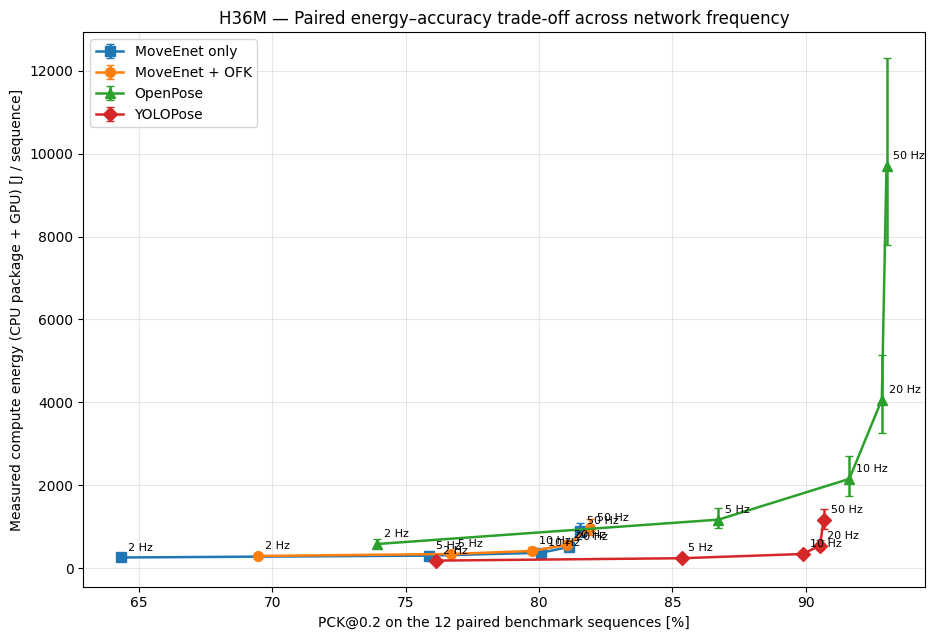

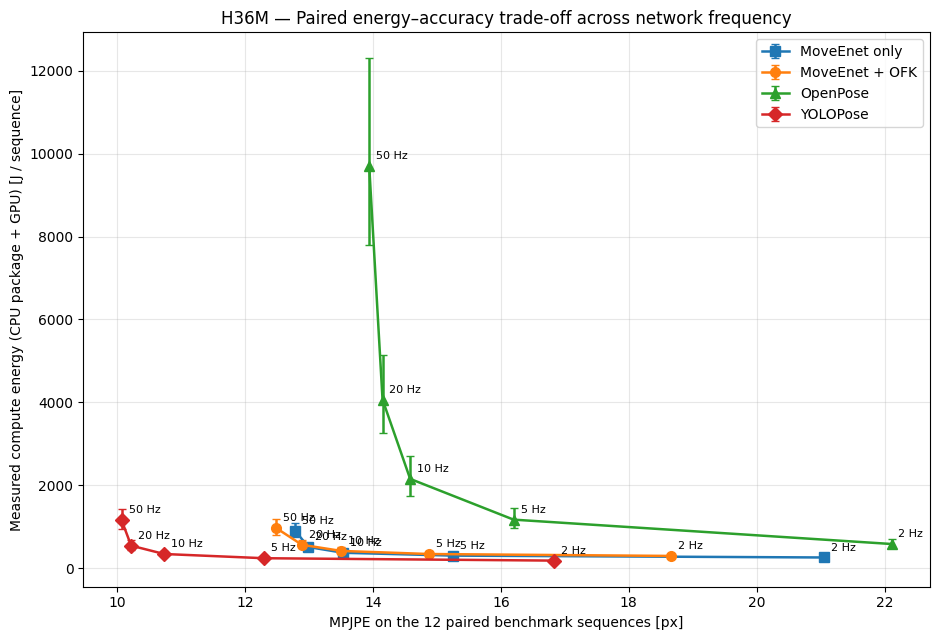

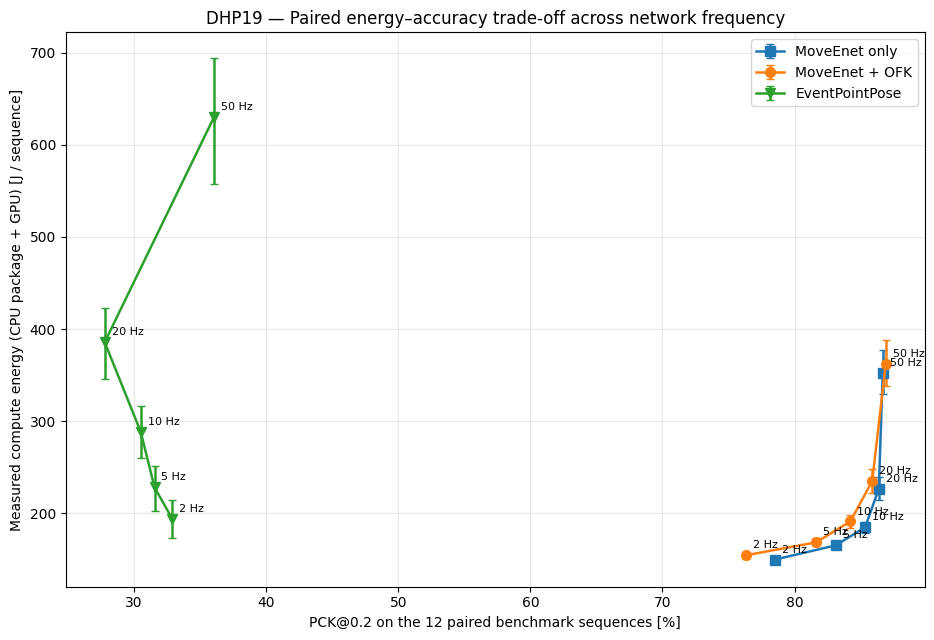

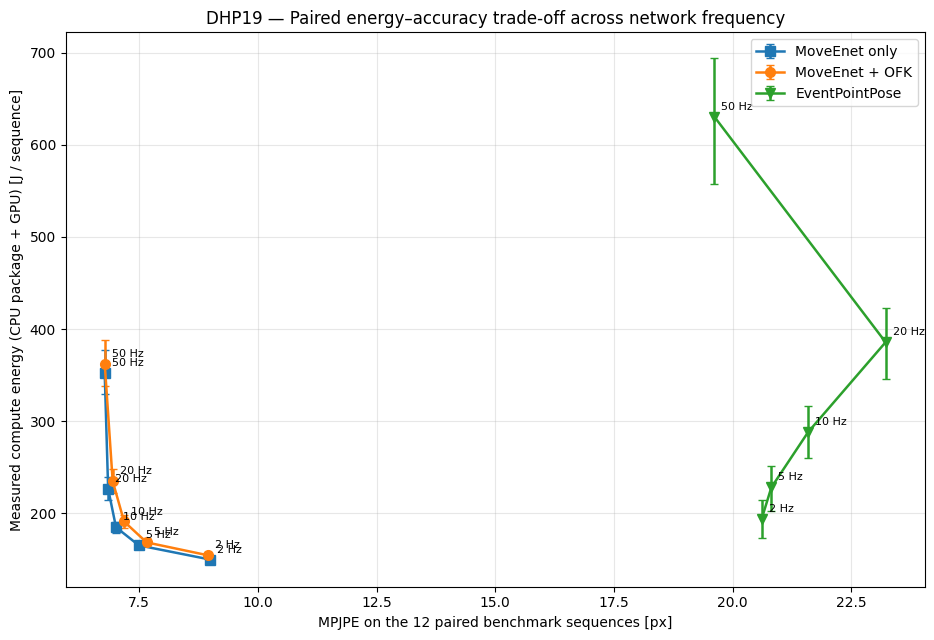

In [12]:
def plot_tradeoff(
    dataset,
    metric="pck_0.2",
    methods=None,
    filename=None,
):

    d = summary[
        summary["dataset"] == dataset
    ].copy()


    if methods is not None:

        d = d[
            d["method"].isin(
                methods
            )
        ]


    method_order = (
        EXPECTED_METHODS[dataset]
        if methods is None
        else methods
    )


    fig, ax = plt.subplots(
        figsize=(9.5, 6.5)
    )


    for method in method_order:

        g = (
            d[
                d["method"] == method
            ]
            .sort_values(
                "detection_rate_hz"
            )
        )


        if g.empty:
            continue


        y = (
            g["energy_mean_j"]
            .to_numpy(dtype=float)
        )


        yerr = np.vstack([

            y
            - g["energy_ci95_low_j"]
              .to_numpy(dtype=float),

            g["energy_ci95_high_j"]
             .to_numpy(dtype=float)
            - y,
        ])


        ax.errorbar(
            g[metric],
            y,
            yerr=yerr,

            marker=
                METHOD_MARKERS.get(
                    method,
                    "o",
                ),

            markersize=7,
            linewidth=1.8,
            capsize=3,

            label=method,
        )


        for _, row in g.iterrows():

            ax.annotate(
                f'{row["detection_rate_hz"]:g} Hz',

                (
                    row[metric],
                    row["energy_mean_j"],
                ),

                xytext=(5, 5),

                textcoords=
                    "offset points",

                fontsize=8,
            )


    if metric == "pck_0.2":

        xlabel = (
            "PCK@0.2 on the 12 paired "
            "benchmark sequences [%]"
        )

    elif metric == "mpjpe_px":

        xlabel = (
            "MPJPE on the 12 paired "
            "benchmark sequences [px]"
        )

    else:

        xlabel = metric


    ax.set_xlabel(
        xlabel
    )


    ax.set_ylabel(
        "Measured compute energy "
        "(CPU package + GPU) "
        "[J / sequence]"
    )


    ax.set_title(
        f"{dataset.upper()} — "
        "Paired energy–accuracy trade-off "
        "across network frequency"
    )


    ax.grid(
        True,
        alpha=0.3,
    )


    ax.legend()


    fig.tight_layout()


    if filename is None:

        filename = (
            f"{dataset}_"
            f"paired_energy_vs_{metric}"
        )


    fig.savefig(
        PLOTS_DIR
        / f"{filename}.png",

        dpi=300,

        bbox_inches="tight",
    )


    fig.savefig(
        PLOTS_DIR
        / f"{filename}.pdf",

        bbox_inches="tight",
    )


    plt.show()


for dataset in [
    "h36m",
    "dhp19",
]:

    plot_tradeoff(
        dataset,
        metric="pck_0.2",
    )

    plot_tradeoff(
        dataset,
        metric="mpjpe_px",
    )


## 10. MoveEnet-only vs MoveEnet + OFK zoom

This is the contribution-specific comparison, while the previous plots retain all baseline methods.


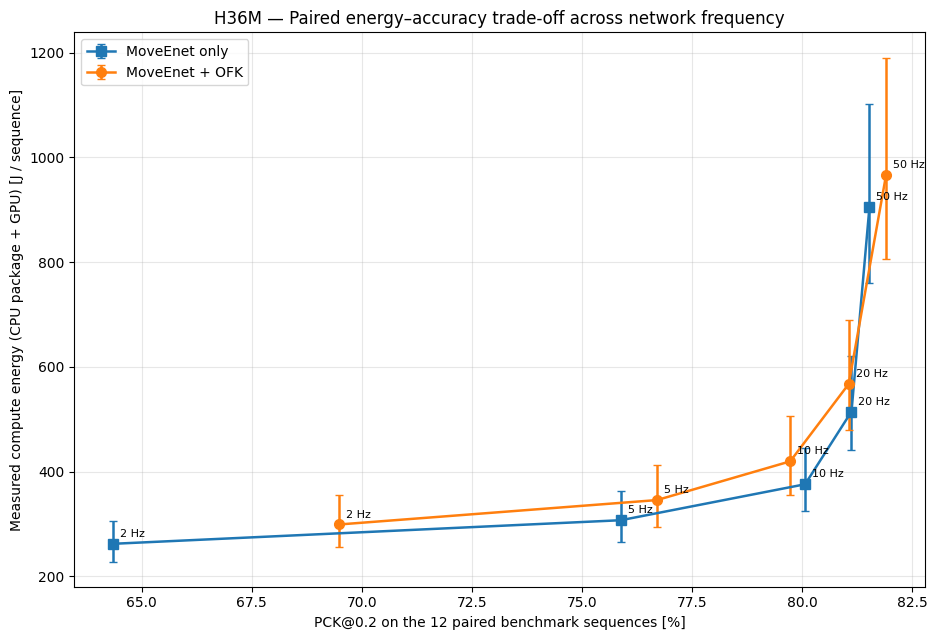

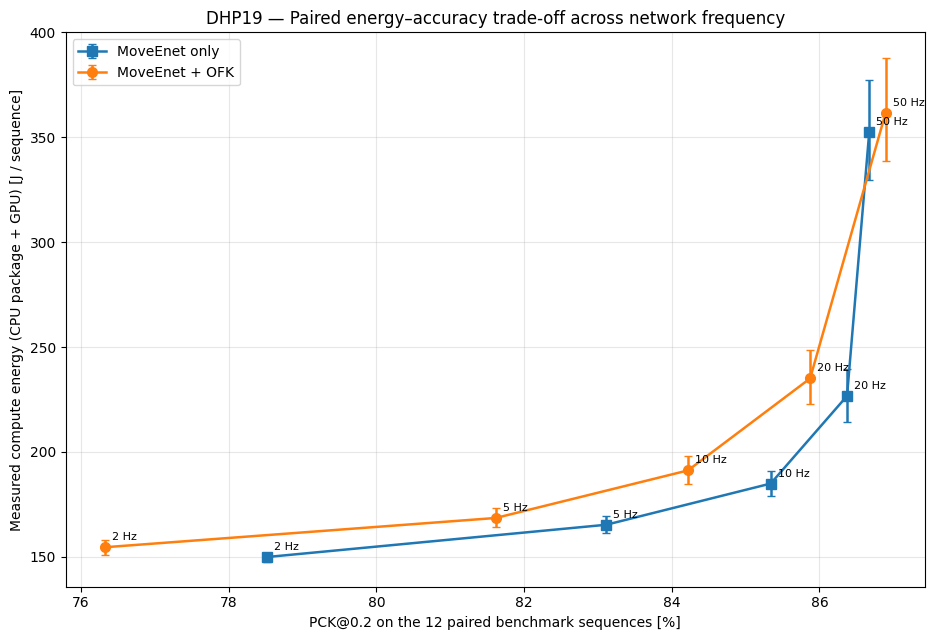

In [13]:
for dataset in [
    "h36m",
    "dhp19",
]:

    plot_tradeoff(
        dataset,
        metric="pck_0.2",

        methods=[
            "MoveEnet only",
            "MoveEnet + OFK",
        ],

        filename=(
            f"{dataset}_"
            "movenet_vs_ofk_"
            "energy_pck_frequency"
        ),
    )


## 11. Direct claim test — reference = MoveEnet-only @ 50 Hz

Each configuration is compared against MoveEnet-only @ 50 Hz on the **same sample**.

Reported:

- energy saving [%]
- PCK change [percentage points]
- PCK retention [%]
- MPJPE change [%]

The desirable region is:

- energy saving > 0
- PCK change close to 0


In [14]:
reference50 = (

    paired[
        (
            paired["method"]
            == "MoveEnet only"
        )

        & np.isclose(
            paired["network_period_s"],
            0.02,
        )
    ]

    [
        [
            "dataset",
            "sample_id",
            "combined_energy_j",
            "pck_0.2",
            "mpjpe_px",
        ]
    ]

    .rename(
        columns={

            "combined_energy_j":
                "ref_energy_j",

            "pck_0.2":
                "ref_pck_0.2",

            "mpjpe_px":
                "ref_mpjpe_px",
        }
    )
)


if len(reference50) != 24:

    raise RuntimeError(
        f"Expected 24 MoveEnet50 reference rows, "
        f"found {len(reference50)}"
    )


relative = paired.merge(
    reference50,

    on=[
        "dataset",
        "sample_id",
    ],

    how="inner",

    validate="many_to_one",
)


relative["rate_hz"] = (
    1.0
    / relative["network_period_s"]
)


relative["energy_saving_pct"] = (

    (
        relative["ref_energy_j"]
        - relative["combined_energy_j"]
    )

    / relative["ref_energy_j"]

    * 100.0
)


relative["pck_delta_pp"] = (

    relative["pck_0.2"]
    - relative["ref_pck_0.2"]
)


relative["pck_retention_pct"] = (

    relative["pck_0.2"]
    / relative["ref_pck_0.2"]

    * 100.0
)


relative["mpjpe_change_pct"] = (

    (
        relative["mpjpe_px"]
        - relative["ref_mpjpe_px"]
    )

    / relative["ref_mpjpe_px"]

    * 100.0
)


relative_rows = []


for key, g in relative.groupby(

    [
        "dataset",
        "method",
        "network_period_s",
        "rate_hz",
    ],

    sort=True,
):

    dataset, method, np_s, hz = key


    e_low, e_high = (
        bootstrap_mean_ci(
            g["energy_saving_pct"]
        )
    )


    p_low, p_high = (
        bootstrap_mean_ci(
            g["pck_delta_pp"]
        )
    )


    relative_rows.append({

        "dataset":
            dataset,

        "method":
            method,

        "network_period_s":
            np_s,

        "detection_rate_hz":
            hz,

        "n_sequences":
            len(g),

        "energy_saving_mean_pct":
            g["energy_saving_pct"].mean(),

        "energy_saving_ci95_low_pct":
            e_low,

        "energy_saving_ci95_high_pct":
            e_high,

        "pck_delta_mean_pp":
            g["pck_delta_pp"].mean(),

        "pck_delta_ci95_low_pp":
            p_low,

        "pck_delta_ci95_high_pp":
            p_high,

        "pck_retention_mean_pct":
            g["pck_retention_pct"].mean(),

        "mpjpe_change_mean_pct":
            g["mpjpe_change_pct"].mean(),
    })


relative_summary = (

    pd.DataFrame(
        relative_rows
    )

    .sort_values(
        [
            "dataset",
            "method",
            "network_period_s",
        ]
    )

    .reset_index(
        drop=True
    )
)


relative_summary.to_csv(

    TABLES_DIR
    / "relative_to_movenet50_paired12.csv",

    index=False,
)


display(
    relative_summary
)


,dataset,method,network_period_s,detection_rate_hz,n_sequences,energy_saving_mean_pct,energy_saving_ci95_low_pct,energy_saving_ci95_high_pct,pck_delta_mean_pp,pck_delta_ci95_low_pp,pck_delta_ci95_high_pp,pck_retention_mean_pct,mpjpe_change_mean_pct
0,dhp19,EventPointPose,0.02,50.0,12,-78.878731,-94.752504,-60.908672,-51.795268,-62.703912,-41.984536,40.872228,225.471392
1,dhp19,EventPointPose,0.05,20.0,12,-9.486474,-17.947218,0.042575,-54.880303,-63.121629,-47.571381,36.493601,246.866191
2,dhp19,EventPointPose,0.10,10.0,12,17.892972,10.075504,25.262822,-53.731066,-63.027885,-45.328947,38.394852,241.419271
3,dhp19,EventPointPose,0.20,5.0,12,34.650920,26.606014,42.347106,-53.255042,-63.088651,-43.487648,39.466321,238.153631
4,dhp19,EventPointPose,0.50,2.0,12,44.200254,36.818728,50.956818,-52.567041,-62.518788,-43.249253,40.025157,236.385241
5,dhp19,MoveEnet + OFK,0.02,50.0,12,-2.677400,-5.199958,-0.717985,0.208706,-0.244590,0.637753,100.206306,0.004165
6,dhp19,MoveEnet + OFK,0.05,20.0,12,33.114155,31.152966,34.996981,-0.834498,-1.583294,-0.126755,99.000212,2.802483
7,dhp19,MoveEnet + OFK,0.10,10.0,12,45.384337,43.442577,47.387356,-2.512856,-3.724249,-1.260585,97.069801,6.870716
8,dhp19,MoveEnet + OFK,0.20,5.0,12,51.732842,49.245510,53.981746,-5.170768,-6.677945,-3.430225,93.990027,14.777909
9,dhp19,MoveEnet + OFK,0.50,2.0,12,55.675572,53.045825,58.034428,-10.524877,-12.766608,-7.989965,87.806356,36.037846


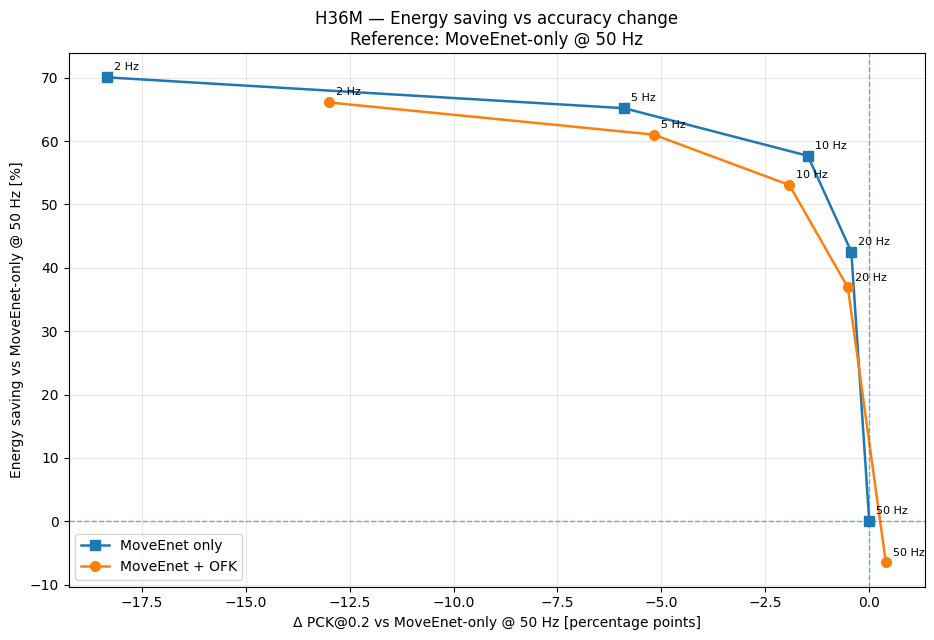

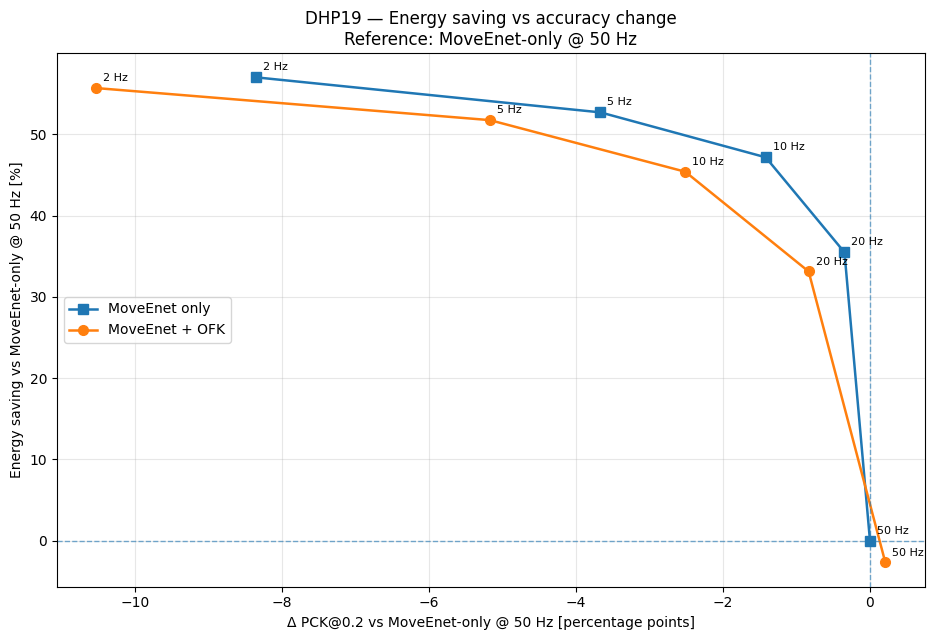

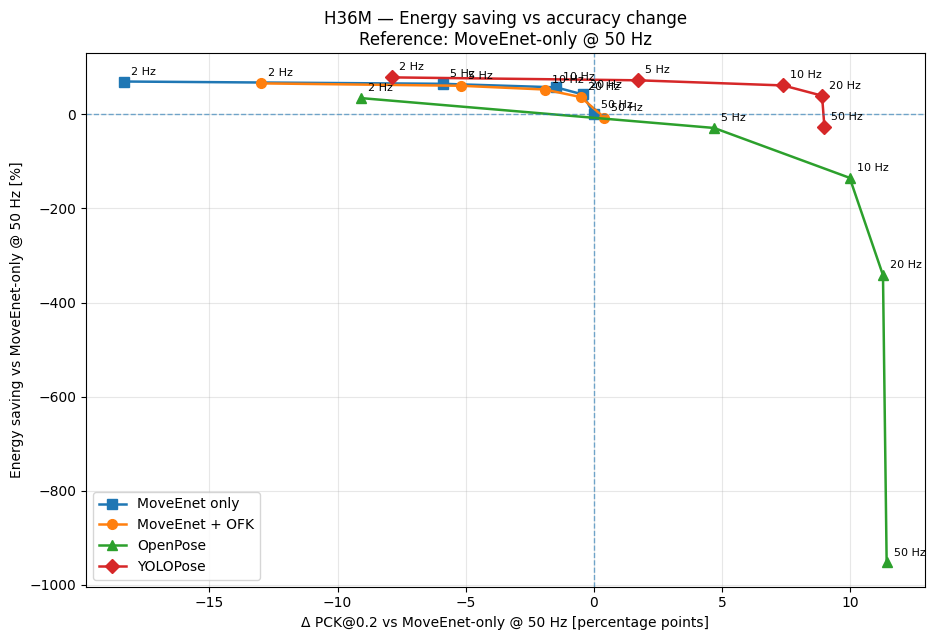

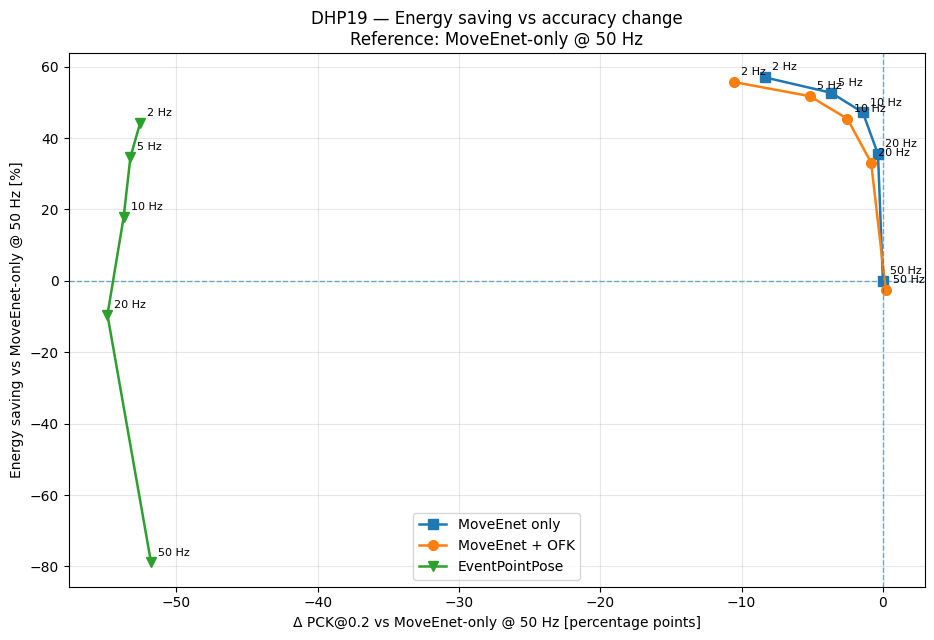

In [15]:
def plot_relative(
    dataset,
    methods=None,
    filename=None,
):

    d = relative_summary[
        relative_summary["dataset"]
        == dataset
    ].copy()


    if methods is not None:

        d = d[
            d["method"].isin(
                methods
            )
        ]


    method_order = (
        EXPECTED_METHODS[dataset]
        if methods is None
        else methods
    )


    fig, ax = plt.subplots(
        figsize=(9.5, 6.5)
    )


    for method in method_order:

        g = (
            d[
                d["method"]
                == method
            ]
            .sort_values(
                "detection_rate_hz"
            )
        )


        if g.empty:
            continue


        ax.plot(
            g["pck_delta_mean_pp"],

            g["energy_saving_mean_pct"],

            marker=
                METHOD_MARKERS.get(
                    method,
                    "o",
                ),

            linewidth=1.8,

            markersize=7,

            label=method,
        )


        for _, row in g.iterrows():

            ax.annotate(
                f'{row["detection_rate_hz"]:g} Hz',

                (
                    row["pck_delta_mean_pp"],
                    row["energy_saving_mean_pct"],
                ),

                xytext=(5, 5),

                textcoords=
                    "offset points",

                fontsize=8,
            )


    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )


    ax.axvline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )


    ax.set_xlabel(
        "Δ PCK@0.2 vs MoveEnet-only "
        "@ 50 Hz [percentage points]"
    )


    ax.set_ylabel(
        "Energy saving vs MoveEnet-only "
        "@ 50 Hz [%]"
    )


    ax.set_title(
        f"{dataset.upper()} — "
        "Energy saving vs accuracy change\n"
        "Reference: MoveEnet-only @ 50 Hz"
    )


    ax.grid(
        True,
        alpha=0.3,
    )


    ax.legend()


    fig.tight_layout()


    if filename is None:

        filename = (
            f"{dataset}_"
            "relative_to_movenet50"
        )


    fig.savefig(
        PLOTS_DIR
        / f"{filename}.png",

        dpi=300,

        bbox_inches="tight",
    )


    fig.savefig(
        PLOTS_DIR
        / f"{filename}.pdf",

        bbox_inches="tight",
    )


    plt.show()


for dataset in [
    "h36m",
    "dhp19",
]:

    plot_relative(
        dataset,

        methods=[
            "MoveEnet only",
            "MoveEnet + OFK",
        ],

        filename=(
            f"{dataset}_"
            "movenet_vs_ofk_"
            "relative50"
        ),
    )


for dataset in [
    "h36m",
    "dhp19",
]:

    plot_relative(
        dataset,

        methods=
            EXPECTED_METHODS[
                dataset
            ],

        filename=(
            f"{dataset}_"
            "all_methods_"
            "relative50"
        ),
    )


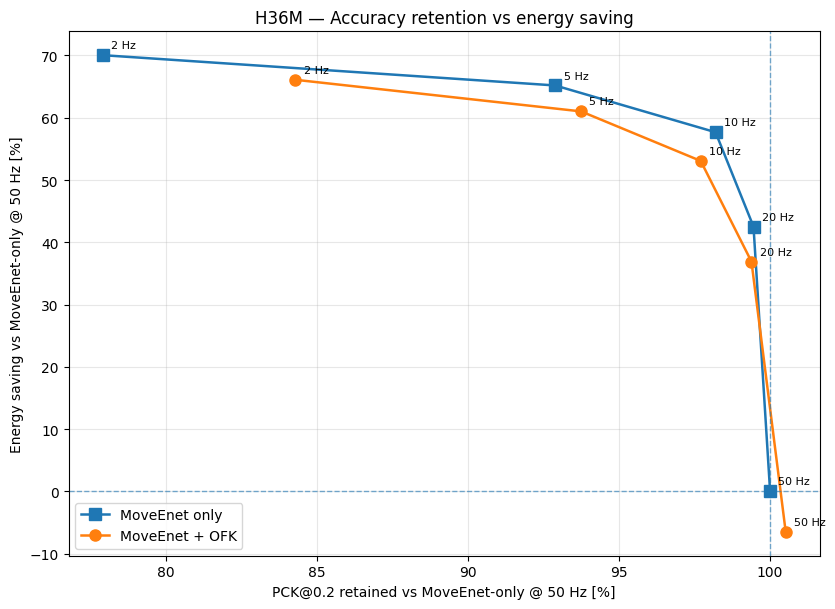

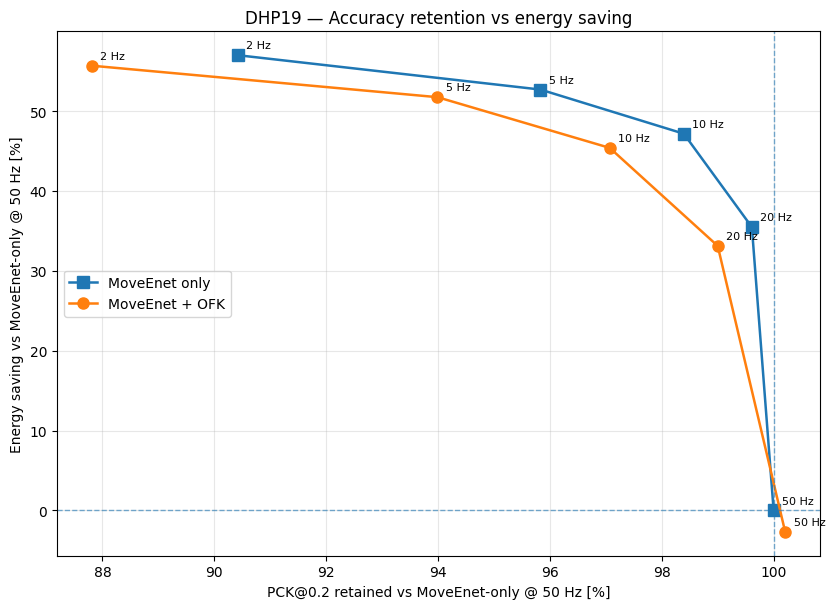

In [18]:
# =============================================================================
# ENERGY SAVING vs ACCURACY RETENTION
# Reference: MoveEnet-only @ 50 Hz
# =============================================================================

def plot_energy_saving_vs_retention(dataset):

    methods = [
        "MoveEnet only",
        "MoveEnet + OFK",
    ]

    d = relative_summary[
        (relative_summary["dataset"] == dataset)
        & relative_summary["method"].isin(methods)
    ].copy()

    fig, ax = plt.subplots(figsize=(8.5, 6.2))

    for method in methods:

        g = (
            d[d["method"] == method]
            .sort_values("detection_rate_hz")
        )

        ax.plot(
            g["pck_retention_mean_pct"],
            g["energy_saving_mean_pct"],
            marker=METHOD_MARKERS.get(method, "o"),
            linewidth=1.8,
            markersize=8,
            label=method,
        )

        for _, row in g.iterrows():

            ax.annotate(
                f'{row["detection_rate_hz"]:g} Hz',
                (
                    row["pck_retention_mean_pct"],
                    row["energy_saving_mean_pct"],
                ),
                xytext=(6, 5),
                textcoords="offset points",
                fontsize=8,
            )

    # MoveEnet 50 Hz reference
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.axvline(
        100,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_xlabel(
        "PCK@0.2 retained vs MoveEnet-only @ 50 Hz [%]"
    )

    ax.set_ylabel(
        "Energy saving vs MoveEnet-only @ 50 Hz [%]"
    )

    ax.set_title(
        f"{dataset.upper()} — Accuracy retention vs energy saving"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()

    name = f"{dataset}_accuracy_retention_vs_energy_saving"

    fig.savefig(
        PLOTS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        PLOTS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.show()


plot_energy_saving_vs_retention("h36m")
plot_energy_saving_vs_retention("dhp19")

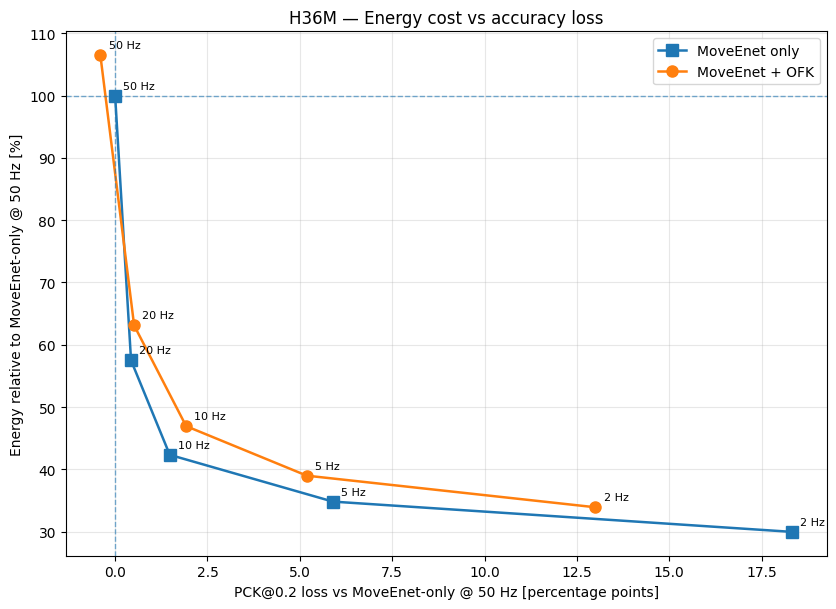

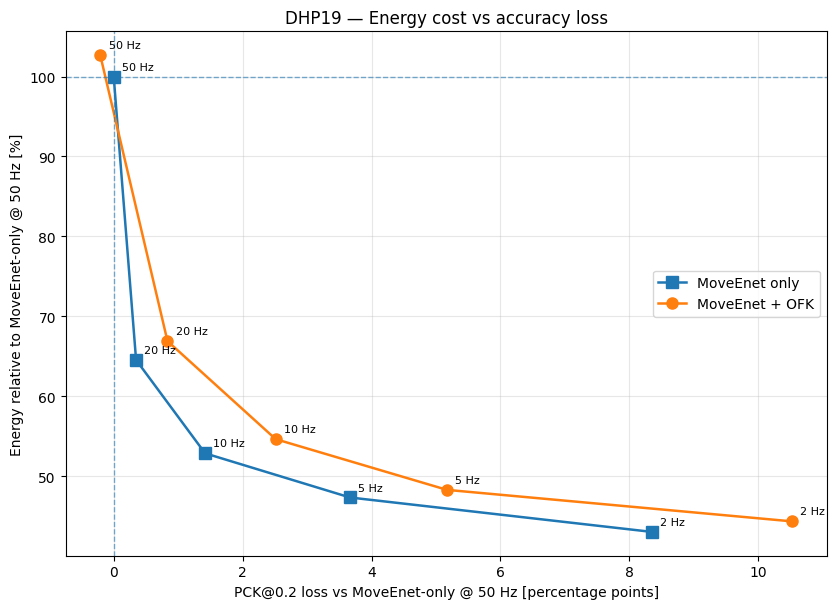

In [19]:
# =============================================================================
# NORMALIZED ENERGY vs PCK LOSS
# Reference: MoveEnet-only @ 50 Hz
# =============================================================================

def plot_energy_remaining_vs_pck_loss(dataset):

    methods = [
        "MoveEnet only",
        "MoveEnet + OFK",
    ]

    d = relative_summary[
        (relative_summary["dataset"] == dataset)
        & relative_summary["method"].isin(methods)
    ].copy()

    d["energy_remaining_pct"] = (
        100.0 - d["energy_saving_mean_pct"]
    )

    d["pck_loss_pp"] = (
        -d["pck_delta_mean_pp"]
    )

    fig, ax = plt.subplots(figsize=(8.5, 6.2))

    for method in methods:

        g = (
            d[d["method"] == method]
            .sort_values("detection_rate_hz")
        )

        ax.plot(
            g["pck_loss_pp"],
            g["energy_remaining_pct"],
            marker=METHOD_MARKERS.get(method, "o"),
            linewidth=1.8,
            markersize=8,
            label=method,
        )

        for _, row in g.iterrows():

            ax.annotate(
                f'{row["detection_rate_hz"]:g} Hz',
                (
                    row["pck_loss_pp"],
                    row["energy_remaining_pct"],
                ),
                xytext=(6, 5),
                textcoords="offset points",
                fontsize=8,
            )

    ax.axhline(
        100,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_xlabel(
        "PCK@0.2 loss vs MoveEnet-only @ 50 Hz [percentage points]"
    )

    ax.set_ylabel(
        "Energy relative to MoveEnet-only @ 50 Hz [%]"
    )

    ax.set_title(
        f"{dataset.upper()} — Energy cost vs accuracy loss"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()

    name = f"{dataset}_normalized_energy_vs_pck_loss"

    fig.savefig(
        PLOTS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        PLOTS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.show()


plot_energy_remaining_vs_pck_loss("h36m")
plot_energy_remaining_vs_pck_loss("dhp19")

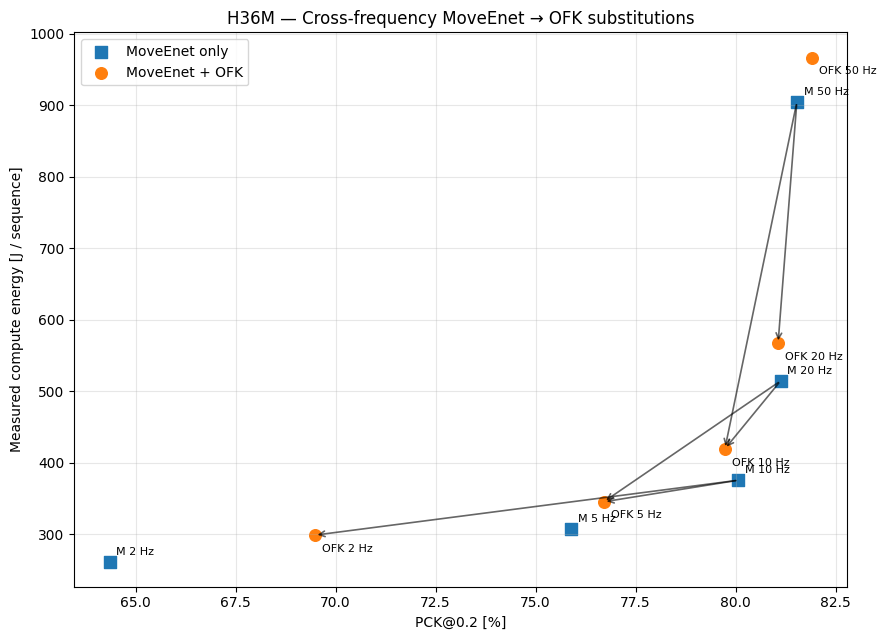

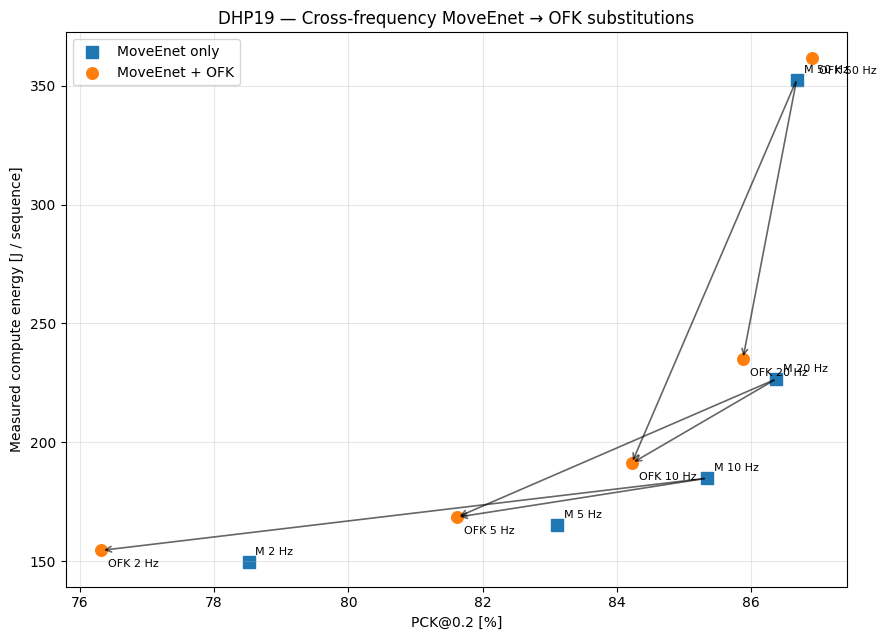

In [20]:
# =============================================================================
# CROSS-FREQUENCY ARROWS
# Higher-rate MoveEnet -> lower-rate OFK
# =============================================================================

ARROW_COMPARISONS = [
    (50, 20),
    (50, 10),
    (20, 10),
    (20, 5),
    (10, 5),
    (10, 2),
]


def plot_cross_frequency_arrows(dataset):

    d = summary[
        (summary["dataset"] == dataset)
        & summary["method"].isin(
            [
                "MoveEnet only",
                "MoveEnet + OFK",
            ]
        )
    ].copy()

    fig, ax = plt.subplots(figsize=(9, 6.5))

    mn = d[
        d["method"] == "MoveEnet only"
    ]

    ofk = d[
        d["method"] == "MoveEnet + OFK"
    ]

    # Plot all MoveEnet points
    ax.scatter(
        mn["pck_0.2"],
        mn["energy_mean_j"],
        marker=METHOD_MARKERS["MoveEnet only"],
        s=70,
        label="MoveEnet only",
    )

    # Plot all OFK points
    ax.scatter(
        ofk["pck_0.2"],
        ofk["energy_mean_j"],
        marker=METHOD_MARKERS["MoveEnet + OFK"],
        s=70,
        label="MoveEnet + OFK",
    )

    for _, row in mn.iterrows():

        ax.annotate(
            f'M {row["detection_rate_hz"]:g} Hz',
            (
                row["pck_0.2"],
                row["energy_mean_j"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    for _, row in ofk.iterrows():

        ax.annotate(
            f'OFK {row["detection_rate_hz"]:g} Hz',
            (
                row["pck_0.2"],
                row["energy_mean_j"],
            ),
            xytext=(5, -12),
            textcoords="offset points",
            fontsize=8,
        )

    # Draw selected cross-frequency substitutions
    for mn_hz, ofk_hz in ARROW_COMPARISONS:

        a = mn[
            np.isclose(
                mn["detection_rate_hz"],
                mn_hz,
            )
        ]

        b = ofk[
            np.isclose(
                ofk["detection_rate_hz"],
                ofk_hz,
            )
        ]

        if len(a) != 1 or len(b) != 1:
            continue

        a = a.iloc[0]
        b = b.iloc[0]

        ax.annotate(
            "",
            xy=(
                b["pck_0.2"],
                b["energy_mean_j"],
            ),
            xytext=(
                a["pck_0.2"],
                a["energy_mean_j"],
            ),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.2,
                alpha=0.6,
            ),
        )

    ax.set_xlabel(
        "PCK@0.2 [%]"
    )

    ax.set_ylabel(
        "Measured compute energy [J / sequence]"
    )

    ax.set_title(
        f"{dataset.upper()} — "
        "Cross-frequency MoveEnet → OFK substitutions"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()

    name = f"{dataset}_cross_frequency_arrows"

    fig.savefig(
        PLOTS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        PLOTS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.show()


plot_cross_frequency_arrows("h36m")
plot_cross_frequency_arrows("dhp19")

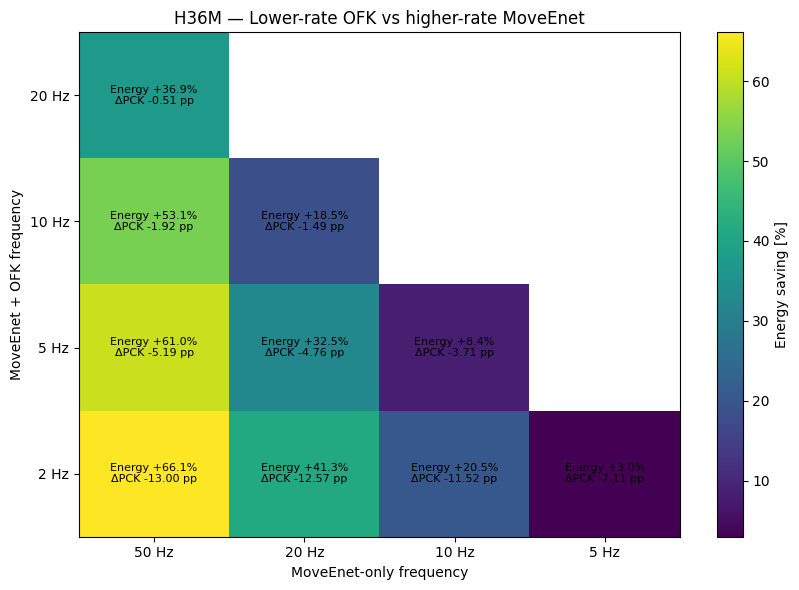

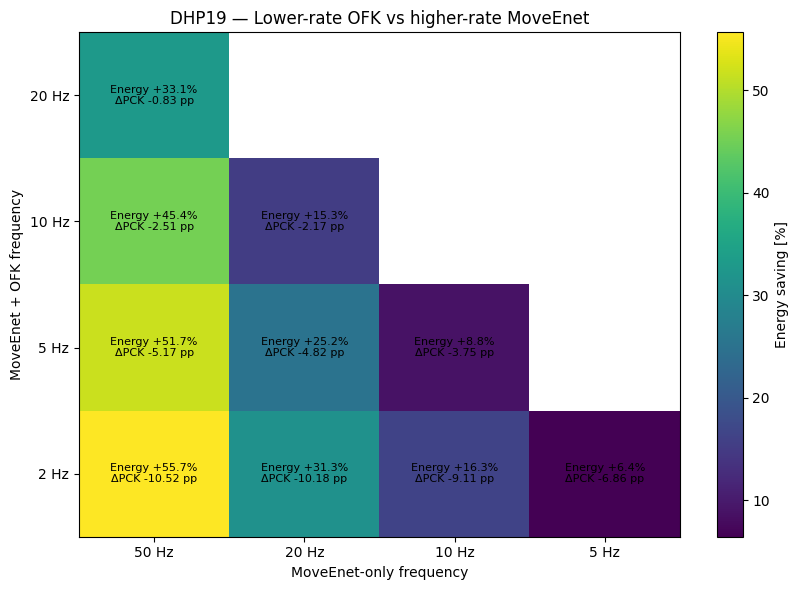

In [22]:
# =============================================================================
# CROSS-FREQUENCY HEATMAP
# OFK lower frequency vs MoveEnet higher frequency
# =============================================================================

def plot_cross_frequency_heatmap(dataset):

    d = cross_summary[
        cross_summary["dataset"] == dataset
    ].copy()

    mn_rates = sorted(
        d["movenet_rate_hz"].unique(),
        reverse=True,
    )

    ofk_rates = sorted(
        d["ofk_rate_hz"].unique(),
        reverse=True,
    )

    # Matrix used only for positioning / background values.
    matrix = np.full(
        (
            len(ofk_rates),
            len(mn_rates),
        ),
        np.nan,
    )

    for i, ofk_hz in enumerate(ofk_rates):

        for j, mn_hz in enumerate(mn_rates):

            row = d[
                np.isclose(
                    d["ofk_rate_hz"],
                    ofk_hz,
                )
                &
                np.isclose(
                    d["movenet_rate_hz"],
                    mn_hz,
                )
            ]

            if len(row) == 1:

                matrix[i, j] = (
                    row.iloc[0][
                        "energy_saving_mean_pct"
                    ]
                )

    fig, ax = plt.subplots(
        figsize=(8.5, 6)
    )

    im = ax.imshow(
        matrix,
        aspect="auto",
    )

    ax.set_xticks(
        np.arange(len(mn_rates))
    )

    ax.set_xticklabels(
        [f"{x:g} Hz" for x in mn_rates]
    )

    ax.set_yticks(
        np.arange(len(ofk_rates))
    )

    ax.set_yticklabels(
        [f"{x:g} Hz" for x in ofk_rates]
    )

    ax.set_xlabel(
        "MoveEnet-only frequency"
    )

    ax.set_ylabel(
        "MoveEnet + OFK frequency"
    )

    ax.set_title(
        f"{dataset.upper()} — "
        "Lower-rate OFK vs higher-rate MoveEnet"
    )

    for i, ofk_hz in enumerate(ofk_rates):

        for j, mn_hz in enumerate(mn_rates):

            row = d[
                np.isclose(
                    d["ofk_rate_hz"],
                    ofk_hz,
                )
                &
                np.isclose(
                    d["movenet_rate_hz"],
                    mn_hz,
                )
            ]

            if len(row) != 1:
                continue

            r = row.iloc[0]

            text = (
                f'Energy {r["energy_saving_mean_pct"]:+.1f}%\n'
                f'ΔPCK {r["pck_delta_mean_pp"]:+.2f} pp'
            )

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )

    cbar = fig.colorbar(
        im,
        ax=ax,
    )

    cbar.set_label(
        "Energy saving [%]"
    )

    fig.tight_layout()

    name = f"{dataset}_cross_frequency_heatmap"

    fig.savefig(
        PLOTS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        PLOTS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.show()


plot_cross_frequency_heatmap("h36m")
plot_cross_frequency_heatmap("dhp19")

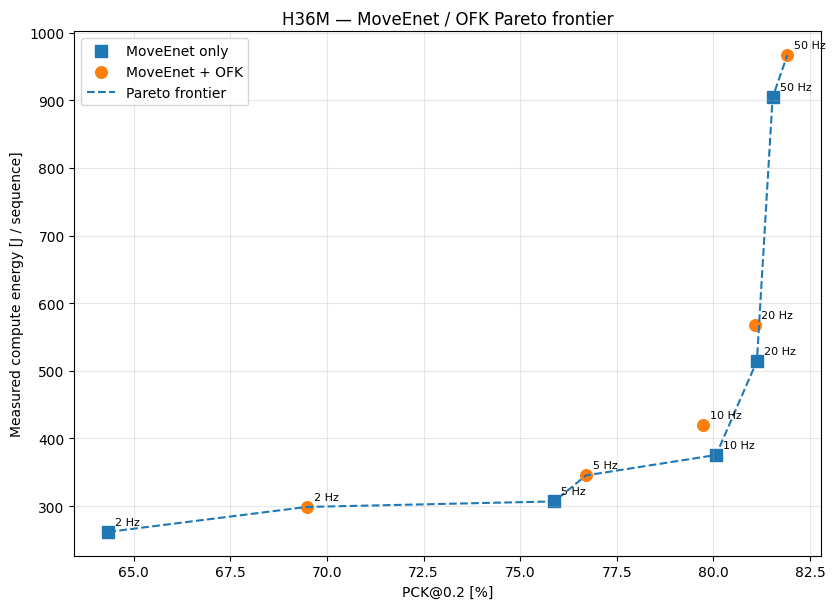

H36M Pareto-optimal operating points:


,method,detection_rate_hz,pck_0.2,energy_mean_j
9,MoveEnet only,2.0,64.345972,261.930830
4,MoveEnet + OFK,2.0,69.476340,298.800596
8,MoveEnet only,5.0,75.884601,306.972830
3,MoveEnet + OFK,5.0,76.703260,345.429039
7,MoveEnet only,10.0,80.070012,375.640948
6,MoveEnet only,20.0,81.124476,514.468095
5,MoveEnet only,50.0,81.531665,904.444239
0,MoveEnet + OFK,50.0,81.911093,966.710971


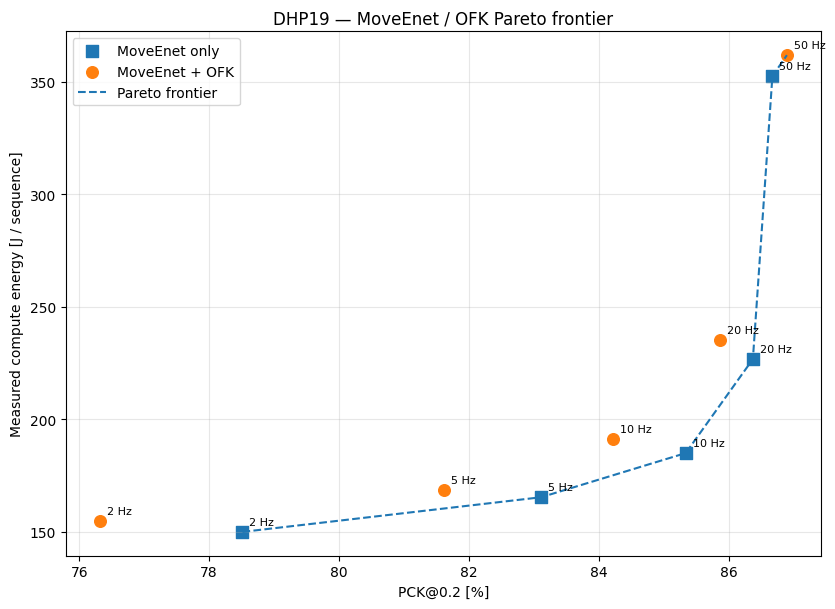

DHP19 Pareto-optimal operating points:


,method,detection_rate_hz,pck_0.2,energy_mean_j
9,MoveEnet only,2.0,78.514125,149.901348
8,MoveEnet only,5.0,83.112877,165.300680
7,MoveEnet only,10.0,85.340381,184.934298
6,MoveEnet only,20.0,86.374374,226.697979
5,MoveEnet only,50.0,86.675126,352.528580
0,MoveEnet + OFK,50.0,86.898271,361.800035


In [23]:
# =============================================================================
# PARETO FRONTIER
# Higher PCK is better, lower energy is better
# =============================================================================

def find_pareto_front(df):

    d = df.copy().reset_index(drop=True)

    pareto = np.ones(
        len(d),
        dtype=bool,
    )

    for i, row_i in d.iterrows():

        for j, row_j in d.iterrows():

            if i == j:
                continue

            better_or_equal_accuracy = (
                row_j["pck_0.2"]
                >= row_i["pck_0.2"]
            )

            better_or_equal_energy = (
                row_j["energy_mean_j"]
                <= row_i["energy_mean_j"]
            )

            strictly_better = (
                row_j["pck_0.2"]
                > row_i["pck_0.2"]
                or
                row_j["energy_mean_j"]
                < row_i["energy_mean_j"]
            )

            if (
                better_or_equal_accuracy
                and better_or_equal_energy
                and strictly_better
            ):

                pareto[i] = False
                break

    d["pareto"] = pareto

    return d


def plot_pareto(dataset):

    d = summary[
        (summary["dataset"] == dataset)
        & summary["method"].isin(
            [
                "MoveEnet only",
                "MoveEnet + OFK",
            ]
        )
    ].copy()

    d = find_pareto_front(d)

    fig, ax = plt.subplots(
        figsize=(8.5, 6.2)
    )

    for method in [
        "MoveEnet only",
        "MoveEnet + OFK",
    ]:

        g = d[
            d["method"] == method
        ]

        ax.scatter(
            g["pck_0.2"],
            g["energy_mean_j"],
            marker=METHOD_MARKERS.get(method, "o"),
            s=70,
            label=method,
        )

        for _, row in g.iterrows():

            ax.annotate(
                f'{row["detection_rate_hz"]:g} Hz',
                (
                    row["pck_0.2"],
                    row["energy_mean_j"],
                ),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    frontier = (
        d[d["pareto"]]
        .sort_values("pck_0.2")
    )

    ax.plot(
        frontier["pck_0.2"],
        frontier["energy_mean_j"],
        linestyle="--",
        linewidth=1.5,
        label="Pareto frontier",
    )

    ax.set_xlabel(
        "PCK@0.2 [%]"
    )

    ax.set_ylabel(
        "Measured compute energy [J / sequence]"
    )

    ax.set_title(
        f"{dataset.upper()} — "
        "MoveEnet / OFK Pareto frontier"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()

    name = f"{dataset}_movenet_ofk_pareto"

    fig.savefig(
        PLOTS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        PLOTS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"{dataset.upper()} Pareto-optimal operating points:"
    )

    display(
        frontier[
            [
                "method",
                "detection_rate_hz",
                "pck_0.2",
                "energy_mean_j",
            ]
        ]
    )


plot_pareto("h36m")
plot_pareto("dhp19")

In [25]:
# =============================================================================
# PAPER-STYLE CROSS-FREQUENCY TABLE
# =============================================================================

claim_table = cross_summary[
    [
        "dataset",
        "movenet_rate_hz",
        "ofk_rate_hz",
        "dnn_rate_reduction_pct",
        "energy_saving_mean_pct",
        "energy_saving_ci95_low_pct",
        "energy_saving_ci95_high_pct",
        "pck_delta_mean_pp",
        "pck_delta_ci95_low_pp",
        "pck_delta_ci95_high_pp",
        "n_paired_sequences",
    ]
].copy()


claim_table = claim_table.sort_values(
    [
        "dataset",
        "energy_saving_mean_pct",
    ],
    ascending=[
        True,
        False,
    ],
).reset_index(drop=True)


claim_table_display = claim_table.copy()

claim_table_display["movenet_rate_hz"] = (
    claim_table_display["movenet_rate_hz"]
    .map(lambda x: f"{x:.0f}")
)

claim_table_display["ofk_rate_hz"] = (
    claim_table_display["ofk_rate_hz"]
    .map(lambda x: f"{x:.0f}")
)

claim_table_display["dnn_rate_reduction_pct"] = (
    claim_table_display["dnn_rate_reduction_pct"]
    .map(lambda x: f"{x:.1f}")
)

for col in [
    "energy_saving_mean_pct",
    "energy_saving_ci95_low_pct",
    "energy_saving_ci95_high_pct",
]:
    claim_table_display[col] = (
        claim_table_display[col]
        .map(lambda x: f"{x:+.1f}")
    )

for col in [
    "pck_delta_mean_pp",
    "pck_delta_ci95_low_pp",
    "pck_delta_ci95_high_pp",
]:
    claim_table_display[col] = (
        claim_table_display[col]
        .map(lambda x: f"{x:+.2f}")
    )


display(claim_table_display)

,dataset,movenet_rate_hz,ofk_rate_hz,dnn_rate_reduction_pct,energy_saving_mean_pct,energy_saving_ci95_low_pct,energy_saving_ci95_high_pct,pck_delta_mean_pp,pck_delta_ci95_low_pp,pck_delta_ci95_high_pp,n_paired_sequences
0,dhp19,50,2,96.0,+55.7,+53.0,+58.0,-10.52,-12.77,-7.99,12
1,dhp19,50,5,90.0,+51.7,+49.2,+54.0,-5.17,-6.68,-3.43,12
2,dhp19,50,10,80.0,+45.4,+43.4,+47.4,-2.51,-3.72,-1.26,12
3,dhp19,50,20,60.0,+33.1,+31.2,+35.0,-0.83,-1.58,-0.13,12
4,dhp19,20,2,90.0,+31.3,+28.3,+34.3,-10.18,-12.56,-7.53,12
5,dhp19,20,5,75.0,+25.2,+22.6,+27.8,-4.82,-6.55,-2.95,12
6,dhp19,10,2,80.0,+16.3,+13.8,+18.3,-9.11,-11.56,-6.45,12
7,dhp19,20,10,50.0,+15.3,+12.9,+17.9,-2.17,-3.64,-0.78,12
8,dhp19,10,5,50.0,+8.8,+6.9,+10.4,-3.75,-5.64,-1.86,12
9,dhp19,5,2,60.0,+6.4,+4.5,+8.1,-6.86,-9.40,-4.20,12


## 12. Cross-frequency paired comparison — lower-rate OFK vs higher-rate MoveEnet-only

This directly tests the central mechanism.

Only comparisons where:

`OFK DNN rate < MoveEnet-only DNN rate`

are retained.


In [16]:
mn = (

    paired[
        paired["method"]
        == "MoveEnet only"
    ]

    [
        [
            "dataset",
            "sample_id",
            "network_period_s",
            "combined_energy_j",
            "pck_0.2",
            "mpjpe_px",
        ]
    ]

    .rename(
        columns={

            "network_period_s":
                "movenet_period_s",

            "combined_energy_j":
                "movenet_energy_j",

            "pck_0.2":
                "movenet_pck",

            "mpjpe_px":
                "movenet_mpjpe",
        }
    )
)


ofk = (

    paired[
        paired["method"]
        == "MoveEnet + OFK"
    ]

    [
        [
            "dataset",
            "sample_id",
            "network_period_s",
            "combined_energy_j",
            "pck_0.2",
            "mpjpe_px",
        ]
    ]

    .rename(
        columns={

            "network_period_s":
                "ofk_period_s",

            "combined_energy_j":
                "ofk_energy_j",

            "pck_0.2":
                "ofk_pck",

            "mpjpe_px":
                "ofk_mpjpe",
        }
    )
)


cross = mn.merge(

    ofk,

    on=[
        "dataset",
        "sample_id",
    ],

    how="inner",

    validate=
        "many_to_many",
)


cross["movenet_rate_hz"] = (
    1.0
    / cross["movenet_period_s"]
)


cross["ofk_rate_hz"] = (
    1.0
    / cross["ofk_period_s"]
)


cross = cross[
    cross["ofk_rate_hz"]
    < cross["movenet_rate_hz"]
].copy()


cross["dnn_rate_reduction_pct"] = (

    1.0

    - (
        cross["ofk_rate_hz"]
        / cross["movenet_rate_hz"]
    )

) * 100.0


cross["energy_saving_pct"] = (

    (
        cross["movenet_energy_j"]
        - cross["ofk_energy_j"]
    )

    / cross["movenet_energy_j"]

) * 100.0


cross["pck_delta_pp"] = (

    cross["ofk_pck"]
    - cross["movenet_pck"]
)


cross["mpjpe_delta_px"] = (

    cross["ofk_mpjpe"]
    - cross["movenet_mpjpe"]
)


cross_rows = []


for key, g in cross.groupby(

    [
        "dataset",
        "movenet_rate_hz",
        "ofk_rate_hz",
    ],

    sort=True,
):

    dataset, mn_hz, ofk_hz = key


    e_low, e_high = (
        bootstrap_mean_ci(
            g["energy_saving_pct"]
        )
    )


    p_low, p_high = (
        bootstrap_mean_ci(
            g["pck_delta_pp"]
        )
    )


    cross_rows.append({

        "dataset":
            dataset,

        "movenet_rate_hz":
            mn_hz,

        "ofk_rate_hz":
            ofk_hz,

        "n_paired_sequences":
            len(g),

        "dnn_rate_reduction_pct":
            g["dnn_rate_reduction_pct"].mean(),

        "energy_saving_mean_pct":
            g["energy_saving_pct"].mean(),

        "energy_saving_ci95_low_pct":
            e_low,

        "energy_saving_ci95_high_pct":
            e_high,

        "pck_delta_mean_pp":
            g["pck_delta_pp"].mean(),

        "pck_delta_ci95_low_pp":
            p_low,

        "pck_delta_ci95_high_pp":
            p_high,

        "mpjpe_delta_mean_px":
            g["mpjpe_delta_px"].mean(),
    })


cross_summary = (

    pd.DataFrame(
        cross_rows
    )

    .sort_values(
        [
            "dataset",
            "movenet_rate_hz",
            "ofk_rate_hz",
        ],

        ascending=[
            True,
            False,
            False,
        ],
    )

    .reset_index(
        drop=True
    )
)


cross_path = (
    TABLES_DIR
    / "ofk_lower_rate_vs_movenet_higher_rate_paired.csv"
)


cross_summary.to_csv(
    cross_path,
    index=False,
)


display(
    cross_summary
)


print(
    "Saved:",
    cross_path,
)


,dataset,movenet_rate_hz,ofk_rate_hz,n_paired_sequences,dnn_rate_reduction_pct,energy_saving_mean_pct,energy_saving_ci95_low_pct,energy_saving_ci95_high_pct,pck_delta_mean_pp,pck_delta_ci95_low_pp,pck_delta_ci95_high_pp,mpjpe_delta_mean_px
0,dhp19,50.0,20.0,12,60.0,33.114155,31.152966,34.996981,-0.834498,-1.583294,-0.126755,0.173151
1,dhp19,50.0,10.0,12,80.0,45.384337,43.442577,47.387356,-2.512856,-3.724249,-1.260585,0.422751
2,dhp19,50.0,5.0,12,90.0,51.732842,49.245510,53.981746,-5.170768,-6.677945,-3.430225,0.912271
3,dhp19,50.0,2.0,12,96.0,55.675572,53.045825,58.034428,-10.524877,-12.766608,-7.989965,2.223700
4,dhp19,20.0,10.0,12,50.0,15.284239,12.913550,17.879333,-2.165721,-3.644088,-0.784487,0.344477
5,dhp19,20.0,5.0,12,75.0,25.208278,22.599473,27.750795,-4.823633,-6.550733,-2.952998,0.833997
6,dhp19,20.0,2.0,12,90.0,31.315430,28.338523,34.294281,-10.177741,-12.560420,-7.528228,2.145426
7,dhp19,10.0,5.0,12,50.0,8.753900,6.887458,10.393660,-3.752367,-5.639948,-1.855374,0.658485
8,dhp19,10.0,2.0,12,80.0,16.251612,13.753614,18.303522,-9.106476,-11.559671,-6.446446,1.969914
9,dhp19,5.0,2.0,12,60.0,6.413958,4.460006,8.099391,-6.858212,-9.404046,-4.203928,1.468719


Saved: /data/MoveEnet_OFK_results/Energy/energy_accuracy_main/analysis_corrected/tables/ofk_lower_rate_vs_movenet_higher_rate_paired.csv


## 13. Candidate configurations under explicit PCK-loss tolerances

For each dataset, this table identifies the cross-frequency MoveEnet-vs-OFK comparison with the highest energy saving while keeping the **mean PCK loss** within:

- 0.5 pp
- 1.0 pp
- 2.0 pp
- 5.0 pp

All thresholds are shown to avoid selecting a single tolerance after observing the results.


In [17]:
PCK_LOSS_LIMITS_PP = [
    0.5,
    1.0,
    2.0,
    5.0,
]


candidate_rows = []


for dataset in [
    "h36m",
    "dhp19",
]:

    d = cross_summary[
        cross_summary["dataset"]
        == dataset
    ].copy()


    for limit in PCK_LOSS_LIMITS_PP:

        eligible = d[

            (
                d["pck_delta_mean_pp"]
                >= -limit
            )

            & (
                d["energy_saving_mean_pct"]
                > 0
            )

        ].copy()


        if eligible.empty:

            candidate_rows.append({

                "dataset":
                    dataset,

                "max_mean_pck_loss_pp":
                    limit,

                "movenet_rate_hz":
                    np.nan,

                "ofk_rate_hz":
                    np.nan,

                "energy_saving_mean_pct":
                    np.nan,

                "pck_delta_mean_pp":
                    np.nan,

                "n_paired_sequences":
                    0,
            })

            continue


        best = eligible.loc[
            eligible[
                "energy_saving_mean_pct"
            ].idxmax()
        ]


        candidate_rows.append({

            "dataset":
                dataset,

            "max_mean_pck_loss_pp":
                limit,

            "movenet_rate_hz":
                best["movenet_rate_hz"],

            "ofk_rate_hz":
                best["ofk_rate_hz"],

            "energy_saving_mean_pct":
                best["energy_saving_mean_pct"],

            "pck_delta_mean_pp":
                best["pck_delta_mean_pp"],

            "n_paired_sequences":
                best["n_paired_sequences"],
        })


candidate_table = (
    pd.DataFrame(
        candidate_rows
    )
)


candidate_path = (
    TABLES_DIR
    / "candidate_energy_saving_under_pck_loss.csv"
)


candidate_table.to_csv(
    candidate_path,
    index=False,
)


display(
    candidate_table
)


print(
    "Saved:",
    candidate_path,
)


,dataset,max_mean_pck_loss_pp,movenet_rate_hz,ofk_rate_hz,energy_saving_mean_pct,pck_delta_mean_pp,n_paired_sequences
0,h36m,0.5,NaN,NaN,NaN,NaN,0
1,h36m,1.0,50.0,20.0,36.896902,-0.514656,12
2,h36m,2.0,50.0,10.0,53.068719,-1.922304,12
3,h36m,5.0,50.0,10.0,53.068719,-1.922304,12
4,dhp19,0.5,NaN,NaN,NaN,NaN,0
5,dhp19,1.0,50.0,20.0,33.114155,-0.834498,12
6,dhp19,2.0,50.0,20.0,33.114155,-0.834498,12
7,dhp19,5.0,50.0,10.0,45.384337,-2.512856,12


Saved: /data/MoveEnet_OFK_results/Energy/energy_accuracy_main/analysis_corrected/tables/candidate_energy_saving_under_pck_loss.csv


## 14. Outputs to inspect

The most important outputs are:

1. **420-key audit**
   - must report `Missing accuracy keys: 0`

2. **Paired merge**
   - must report `420/420 paired rows`

3. Full baseline plots:
   - H36M Energy × PCK × Frequency
   - DHP19 Energy × PCK × Frequency
   - corresponding MPJPE plots

4. Contribution-specific plots:
   - MoveEnet-only vs MoveEnet + OFK

5. Direct claim plot:
   - Energy saving vs PCK change relative to MoveEnet-only @ 50 Hz

6. Quantitative tables:
   - `ofk_lower_rate_vs_movenet_higher_rate_paired.csv`
   - `candidate_energy_saving_under_pck_loss.csv`

Do not interpret the energy-saving claim until the 420-key audit passes.
